In [2]:
import pandas as pd
from supabase import create_client

url = "https://wrprmiiyzwoulpaurthb.supabase.co"
key = "sb_publishable_etOa8Ca_IDmBeO_-YNb3OA_U3OmhRTZ"
supabase = create_client(url, key)

all_data = []
page_size = 1000
offset = 0

while True:
    response = supabase.table("ranking_by_category") \
        .select("*") \
        .eq("카테고리", "스포츠/레저") \
        .range(offset, offset + page_size - 1) \
        .execute()
    
    if not response.data:
        break
    all_data.extend(response.data)
    offset += page_size

df = pd.DataFrame(all_data)
print("총 행 수:", len(df))
print("\n날짜별 행 수:")
print(df['수집날짜'].value_counts().sort_index())
df.head()

총 행 수: 12496

날짜별 행 수:
수집날짜
2026-06-04    1019
2026-06-05    1019
2026-06-06    1019
2026-06-07    1019
2026-06-08    1019
2026-06-09    1019
2026-06-10    1019
2026-06-11    1019
2026-06-12     208
2026-06-13     213
2026-06-14     205
2026-06-15     266
2026-06-16     207
2026-06-17     188
2026-06-18    1019
2026-06-19    1019
2026-06-20    1019
Name: count, dtype: int64


,id,브랜드,상품명,가격,수집날짜,순위,카테고리,리뷰수,리뷰점수
0,4078,데상트,듀얼리스 우븐 반팔 티셔츠 블랙 SR121DTS31,103550,2026-06-04,1,스포츠/레저,0,0
1,4079,데상트,터프 백그래픽 반팔 티셔츠 블랙 SR123UTS23,59850,2026-06-04,2,스포츠/레저,0,0
2,4080,나이키,대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블...,135000,2026-06-04,3,스포츠/레저,0,0
3,4081,데상트,터프 스몰 워딩 레귤러핏 폴로 반팔 티셔츠 블랙 SR323UPS74,84550,2026-06-04,4,스포츠/레저,0,0
4,4082,전북현대모터스FC,BLACK LABEL : unexpected charm 필드홈 풀마킹(이승우),219000,2026-06-04,5,스포츠/레저,0,0


In [3]:
def load_ranking_data(category=None, start_date=None, end_date=None):
    """
    무신사 랭킹 데이터를 Supabase에서 가져오는 함수
    
    Args:
        category: 카테고리명 (예: '스포츠/레저'). None이면 전체 카테고리
        start_date: 시작 날짜 (예: '2026-06-04'). None이면 전체 기간
        end_date: 종료 날짜 (예: '2026-06-19'). None이면 전체 기간
    
    Returns:
        DataFrame
    """
    all_data = []
    offset = 0
    page_size = 1000
    
    while True:
        query = supabase.table("ranking_by_category").select("*")
        
        # 카테고리 필터
        if category is not None:
            query = query.eq("카테고리", category)
        
        # 날짜 필터
        if start_date is not None:
            query = query.gte("수집날짜", start_date)
        if end_date is not None:
            query = query.lte("수집날짜", end_date)
        
        # 페이지네이션
        response = query.range(offset, offset + page_size - 1).execute()
        
        if not response.data:
            break
        
        all_data.extend(response.data)
        offset += page_size
    
    df = pd.DataFrame(all_data)
    
    if len(df) > 0:
        df['수집날짜'] = pd.to_datetime(df['수집날짜'])
    
    print(f"불러온 데이터: {len(df)}행")
    return df

In [4]:
#로딩 함수 동작 테스트

print('테스트 1: 스포츠/레저 전체')
df_test1 = load_ranking_data(category='스포츠/레저')

print('테스트 2: 스포츠/레저 + 6/12 이후')
df_test2 = load_ranking_data(category='스포츠/레저', start_date='2026-06-12')

print('테스트 3: 전체 카테고리 + 6/18 ~ 6/19')
df_test3 = load_ranking_data(start_date='2026-06-18', end_date='2026-06-19')

테스트 1: 스포츠/레저 전체
불러온 데이터: 12496행
테스트 2: 스포츠/레저 + 6/12 이후
불러온 데이터: 4344행
테스트 3: 전체 카테고리 + 6/18 ~ 6/19
불러온 데이터: 9171행


In [5]:
후원_브랜드 = ['나이키', '아디다스', '푸마']
비후원_브랜드 = ['살로몬', '뉴발란스', '언더아머']

대상_브랜드 = 후원_브랜드 + 비후원_브랜드
df_target = df[df['브랜드'].isin(대상_브랜드)].copy()

df_target['그룹'] = df_target['브랜드'].apply(
    lambda x: '후원' if x in 후원_브랜드 else '비후원'
)
print("총 행 갯수:", len(df_target))
print("\n브랜드별 행 갯수:")
print(df_target['브랜드'].value_counts())
print("\n그룹별 행 갯수:")
print(df_target['그룹'].value_counts())
      

총 행 갯수: 3685

브랜드별 행 갯수:
브랜드
아디다스    1570
뉴발란스     942
살로몬      482
나이키      463
언더아머     169
푸마        59
Name: count, dtype: int64

그룹별 행 갯수:
그룹
후원     2092
비후원    1593
Name: count, dtype: int64


In [6]:
df_target['수집날짜'] = pd.to_datetime(df_target['수집날짜'])

group_daily = df_target.groupby(['수집날짜', '그룹'])['순위'].mean().reset_index()
group_daily.columns = ['수집날짜', '그룹', '평균순위']

print(group_daily)

         수집날짜   그룹        평균순위
0  2026-06-04  비후원  517.800000
1  2026-06-04   후원  592.333333
2  2026-06-05  비후원  467.030303
3  2026-06-05   후원  622.357616
4  2026-06-06  비후원  458.604396
5  2026-06-06   후원  465.111111
6  2026-06-07  비후원  490.187500
7  2026-06-07   후원  635.422222
8  2026-06-08  비후원  501.287037
9  2026-06-08   후원  590.754237
10 2026-06-09  비후원  477.877778
11 2026-06-09   후원  561.322835
12 2026-06-10  비후원  389.857143
13 2026-06-10   후원  535.146341
14 2026-06-11  비후원  468.032967
15 2026-06-11   후원  596.669355
16 2026-06-12  비후원  470.973333
17 2026-06-12   후원  512.877863
18 2026-06-13  비후원  570.379747
19 2026-06-13   후원  551.770992
20 2026-06-14  비후원  445.412371
21 2026-06-14   후원  637.653846
22 2026-06-15  비후원  457.447154
23 2026-06-15   후원  459.992754
24 2026-06-16  비후원  498.000000
25 2026-06-16   후원  384.585366
26 2026-06-17  비후원  420.514286
27 2026-06-17   후원  439.803419
28 2026-06-18  비후원  547.084906
29 2026-06-18   후원  415.965217
30 2026-06-19  비후원  422.858586
31 2026-

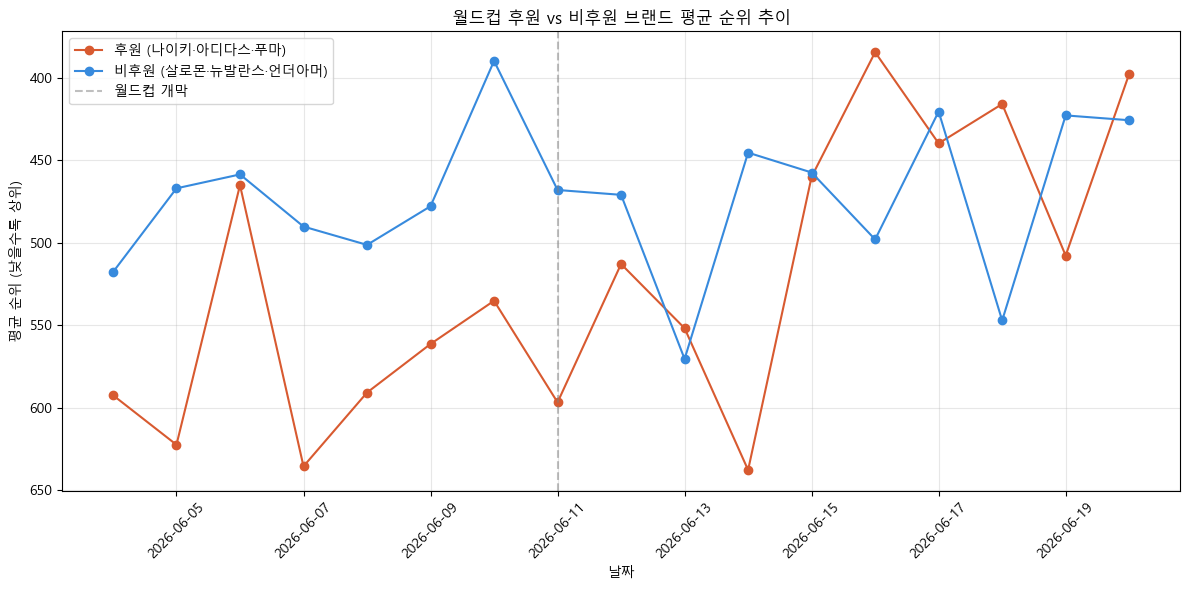

In [7]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False


후원_df = group_daily[group_daily['그룹'] == '후원']
비후원_df = group_daily[group_daily['그룹'] == '비후원']

plt.figure(figsize=(12, 6))
plt.plot(후원_df['수집날짜'], 후원_df['평균순위'], marker='o', label='후원 (나이키·아디다스·푸마)', color='#D85A30')
plt.plot(비후원_df['수집날짜'], 비후원_df['평균순위'], marker='o', label='비후원 (살로몬·뉴발란스·언더아머)', color='#378ADD')


plt.axvline(x=pd.to_datetime('2026-06-11'), color='gray', linestyle='--', alpha=0.5, label='월드컵 개막')

plt.gca().invert_yaxis()  
plt.xlabel('날짜')
plt.ylabel('평균 순위 (낮을수록 상위)')
plt.title('월드컵 후원 vs 비후원 브랜드 평균 순위 추이')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


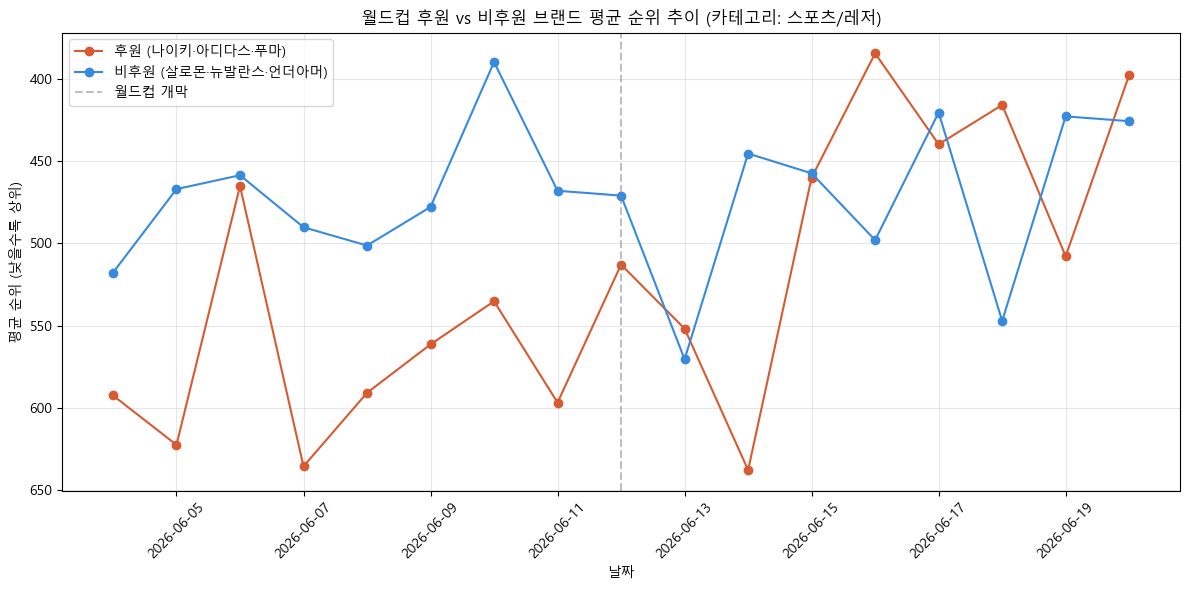

In [8]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Malgun Gothic'  
matplotlib.rcParams['axes.unicode_minus'] = False

후원_df = group_daily[group_daily['그룹'] == '후원']
비후원_df = group_daily[group_daily['그룹'] == '비후원']

plt.figure(figsize=(12, 6))
plt.plot(후원_df['수집날짜'], 후원_df['평균순위'], marker='o', label='후원 (나이키·아디다스·푸마)', color='#D85A30')
plt.plot(비후원_df['수집날짜'], 비후원_df['평균순위'], marker='o', label='비후원 (살로몬·뉴발란스·언더아머)', color='#378ADD')

plt.axvline(x=pd.to_datetime('2026-06-12'), color='gray', linestyle='--', alpha=0.5, label='월드컵 개막')

plt.gca().invert_yaxis()
plt.xlabel('날짜')
plt.ylabel('평균 순위 (낮을수록 상위)')
plt.title('월드컵 후원 vs 비후원 브랜드 평균 순위 추이 (카테고리: 스포츠/레저)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df_target['시기'] = df_target['수집날짜'].apply(
    lambda x: '월드컵 전' if x < pd.to_datetime('2026-06-12') else '월드컵 후'
)

비교표 = df_target.groupby(['시기', '그룹'])['순위'].mean().reset_index()
비교표.columns = ['시기', '그룹', '평균순위']
print(비교표)

      시기   그룹        평균순위
0  월드컵 전  비후원  471.880983
1  월드컵 전   후원  580.361593
2  월드컵 후  비후원  472.841463
3  월드컵 후   후원  477.850854


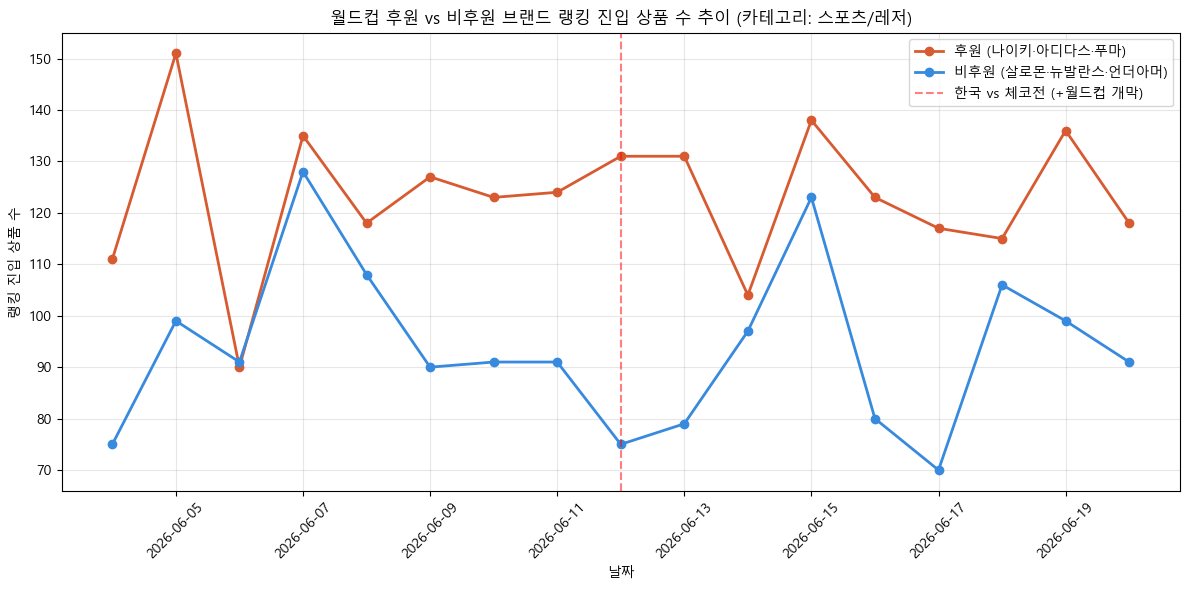


월드컵 전후 평균 상품 수:
      시기   그룹  총 상품 수
0  월드컵 전  비후원     773
1  월드컵 전   후원     979
2  월드컵 후  비후원     820
3  월드컵 후   후원    1113

일평균 상품 수 (그룹별):
      시기   그룹         상품수
0  월드컵 전  비후원   96.625000
1  월드컵 전   후원  122.375000
2  월드컵 후  비후원   91.111111
3  월드컵 후   후원  123.666667


In [10]:
count_daily = df_target.groupby(['수집날짜', '그룹']).size().reset_index(name='상품수')

plt.figure(figsize=(12, 6))

후원_count = count_daily[count_daily['그룹'] == '후원']
비후원_count = count_daily[count_daily['그룹'] == '비후원']

plt.plot(후원_count['수집날짜'], 후원_count['상품수'], 
         marker='o', label='후원 (나이키·아디다스·푸마)', color='#D85A30', linewidth=2)
plt.plot(비후원_count['수집날짜'], 비후원_count['상품수'], 
         marker='o', label='비후원 (살로몬·뉴발란스·언더아머)', color='#378ADD', linewidth=2)

plt.axvline(x=pd.to_datetime('2026-06-12'), color='red', linestyle='--', alpha=0.5, label='한국 vs 체코전 (+월드컵 개막)')

plt.xlabel('날짜')
plt.ylabel('랭킹 진입 상품 수')
plt.title('월드컵 후원 vs 비후원 브랜드 랭킹 진입 상품 수 추이 (카테고리: 스포츠/레저)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n월드컵 전후 평균 상품 수:")
df_target_copy = df_target.copy()
df_target_copy['시기'] = df_target_copy['수집날짜'].apply(
    lambda x: '월드컵 전' if x < pd.to_datetime('2026-06-12') else '월드컵 후'
)
result = df_target_copy.groupby(['시기', '그룹']).size().reset_index(name='총 상품 수')
print(result)

print("\n일평균 상품 수 (그룹별):")
일평균 = df_target_copy.groupby(['시기', '그룹', '수집날짜']).size().reset_index(name='상품수')
print(일평균.groupby(['시기', '그룹'])['상품수'].mean().reset_index())


In [11]:
후원_브랜드_정보 = {
    '나이키': {
        '후원국_수': 12,
        '후원국_리스트': '호주, 브라질, 캐나다, 대한민국, 크로아티아, 미국, 프랑스, 네덜란드, 잉글랜드, 노르웨이, 튀르키예, 우루과이'
    },
    '아디다스': {
        '후원국_수': 14,
        '후원국_리스트': '독일, 사우디아라비아, 알제리, 아르헨티나, 벨기에, 카타르, 콜롬비아, 퀴라소, 스코틀랜드, 스페인, 일본, 멕시코, 스웨덴, 자메이카'
    },
    '푸마': {
        '후원국_수': 11,
        '후원국_리스트': '남아프리카공화국, 체코, 스위스, 세네갈, 포르투갈, 파라과이, 뉴질랜드, 모로코, 가나, 이집트, 코트디부아르, 오스트리아'
    },
}

result = df_target[df_target['그룹'] == '후원'].groupby('브랜드').agg(
    진입_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean')
).reset_index()

result['후원_국가_수'] = result['브랜드'].map(lambda x: 후원_브랜드_정보[x]['후원국_수'])
result['후원국_리스트'] = result['브랜드'].map(lambda x: 후원_브랜드_정보[x]['후원국_리스트'])


result = result[['브랜드', '후원_국가_수', '진입_상품_수', '평균_순위', '후원국_리스트']]
result = result.sort_values('후원_국가_수', ascending=False)

for _, row in result.iterrows():
    print(f"\n[{row['브랜드']}]")
    print(f"  후원 국가 수: {row['후원_국가_수']}개")
    print(f"  무신사 랭킹 진입 상품 수: {row['진입_상품_수']}개")
    print(f"  평균 순위: {row['평균_순위']:.2f}위")


[아디다스]
  후원 국가 수: 14개
  무신사 랭킹 진입 상품 수: 1570개
  평균 순위: 536.18위

[나이키]
  후원 국가 수: 12개
  무신사 랭킹 진입 상품 수: 463개
  평균 순위: 482.39위

[푸마]
  후원 국가 수: 11개
  무신사 랭킹 진입 상품 수: 59개
  평균 순위: 591.03위


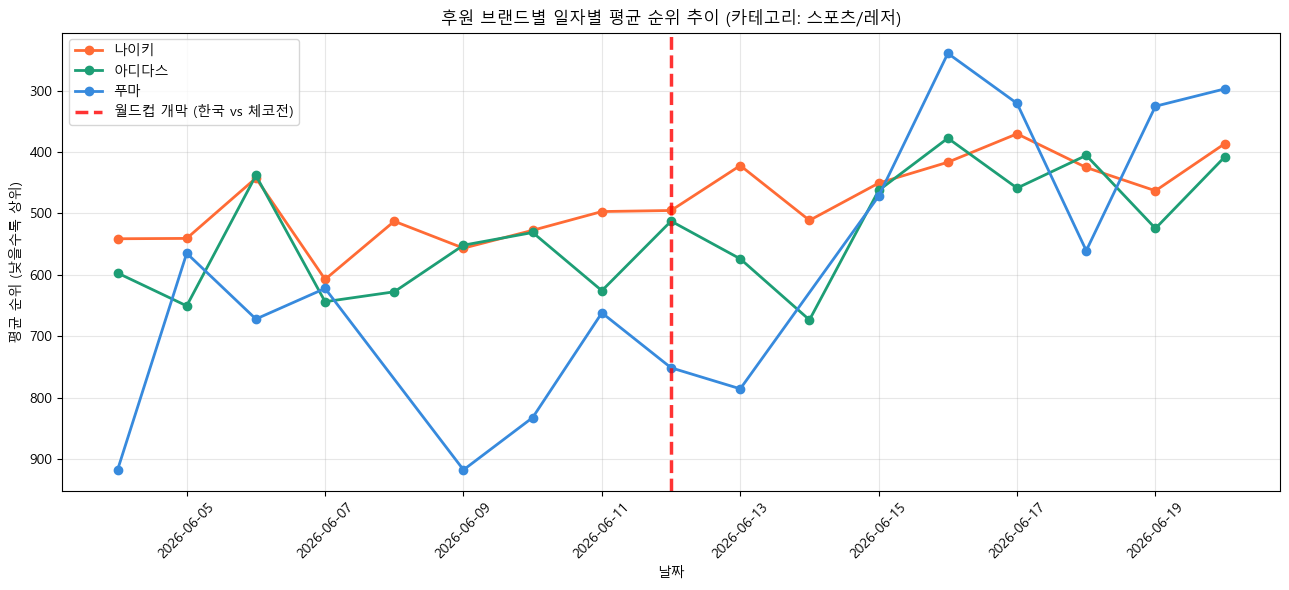

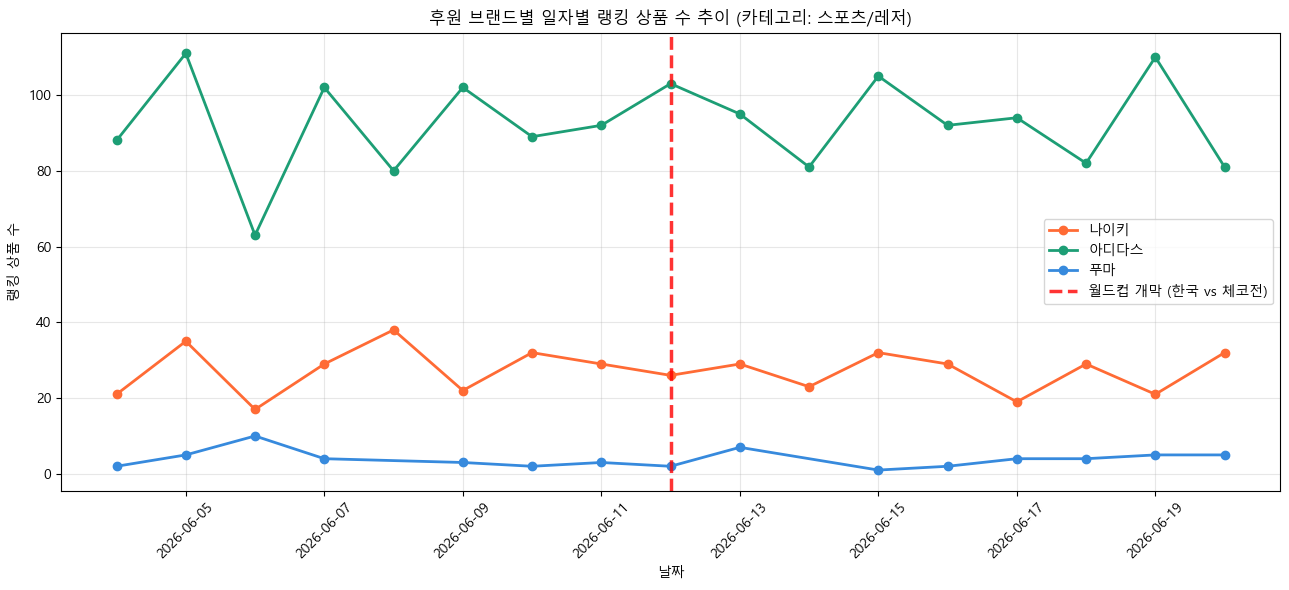


=== 후원 브랜드별 월드컵 전후 스포츠/레저 카테고리 평균 순위 변화 (6/12 기준) ===

[나이키]  531.3위 → 437.0위  (+94.3위 변화)
[아디다스]  590.7위 → 489.2위  (+101.5위 변화)
[푸마]  699.1위 → 486.5위  (+212.6위 변화)

=== 후원 브랜드별 월드컵 전후 일평균 랭킹 상품 수 변화 (스포츠/레저 카테고리) (6/12 기준) ===

[나이키]  27.9개/일 → 26.7개/일  (-1.2개)
[아디다스]  90.9개/일 → 93.7개/일  (+2.8개)
[푸마]  4.1개/일 → 3.8개/일  (-0.4개)


In [12]:
후원_df = df_target[df_target['그룹'] == '후원'].copy()
brand_daily = 후원_df.groupby(['수집날짜', '브랜드'])['순위'].mean().reset_index()

# 그래프 1: 평균 순위 추이
plt.figure(figsize=(13, 6))
colors = {'나이키': '#FF6B35', '아디다스': '#1D9E75', '푸마': '#378ADD'}
for brand in ['나이키', '아디다스', '푸마']:
    brand_data = brand_daily[brand_daily['브랜드'] == brand]
    plt.plot(brand_data['수집날짜'], brand_data['순위'], 
             marker='o', label=brand, color=colors[brand], linewidth=2)

plt.axvline(x=pd.to_datetime('2026-06-12'), color='red', linestyle='--', 
            linewidth=2.5, alpha=0.8, label='월드컵 개막 (한국 vs 체코전)')

plt.gca().invert_yaxis()
plt.xlabel('날짜')
plt.ylabel('평균 순위 (낮을수록 상위)')
plt.title('후원 브랜드별 일자별 평균 순위 추이 (카테고리: 스포츠/레저)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 그래프 2: 랭킹 상품 수 추이
brand_count_daily = 후원_df.groupby(['수집날짜', '브랜드']).size().reset_index(name='상품수')
plt.figure(figsize=(13, 6))
for brand in ['나이키', '아디다스', '푸마']:
    brand_data = brand_count_daily[brand_count_daily['브랜드'] == brand]
    plt.plot(brand_data['수집날짜'], brand_data['상품수'], 
             marker='o', label=brand, color=colors[brand], linewidth=2)

plt.axvline(x=pd.to_datetime('2026-06-12'), color='red', linestyle='--', 
            linewidth=2.5, alpha=0.8, label='월드컵 개막 (한국 vs 체코전)')

plt.xlabel('날짜')
plt.ylabel('랭킹 상품 수')
plt.title('후원 브랜드별 일자별 랭킹 상품 수 추이 (카테고리: 스포츠/레저)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 숫자 분석 (6/12 기준)
print("\n=== 후원 브랜드별 월드컵 전후 스포츠/레저 카테고리 평균 순위 변화 (6/12 기준) ===\n")
for brand in ['나이키', '아디다스', '푸마']:
    before = 후원_df[(후원_df['브랜드'] == brand) & 
                     (후원_df['수집날짜'] < pd.to_datetime('2026-06-12'))]['순위'].mean()
    after = 후원_df[(후원_df['브랜드'] == brand) & 
                    (후원_df['수집날짜'] >= pd.to_datetime('2026-06-12'))]['순위'].mean()
    
    print(f"[{brand}]  {before:.1f}위 → {after:.1f}위  ({before - after:+.1f}위 변화)")

print("\n=== 후원 브랜드별 월드컵 전후 일평균 랭킹 상품 수 변화 (스포츠/레저 카테고리) (6/12 기준) ===\n")
for brand in ['나이키', '아디다스', '푸마']:
    before_data = 후원_df[(후원_df['브랜드'] == brand) & 
                          (후원_df['수집날짜'] < pd.to_datetime('2026-06-12'))]
    after_data = 후원_df[(후원_df['브랜드'] == brand) & 
                         (후원_df['수집날짜'] >= pd.to_datetime('2026-06-12'))]
    
    before_days = before_data['수집날짜'].nunique()
    after_days = after_data['수집날짜'].nunique()
    
    before_avg = len(before_data) / before_days
    after_avg = len(after_data) / after_days
    
    print(f"[{brand}]  {before_avg:.1f}개/일 → {after_avg:.1f}개/일  ({after_avg - before_avg:+.1f}개)")

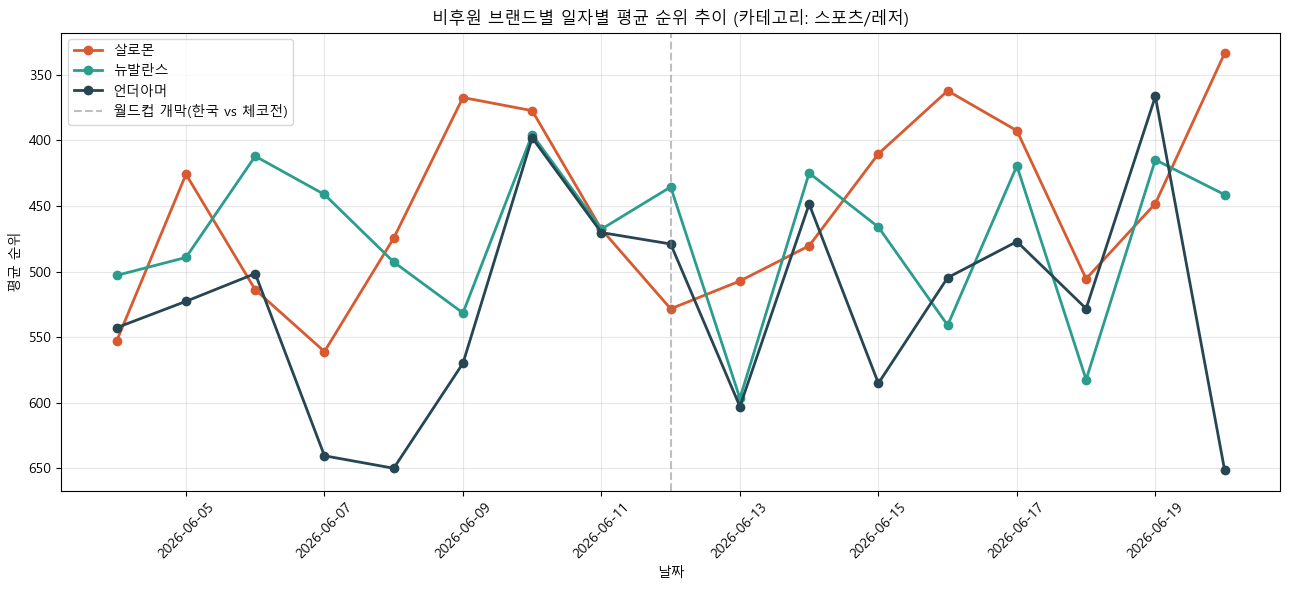

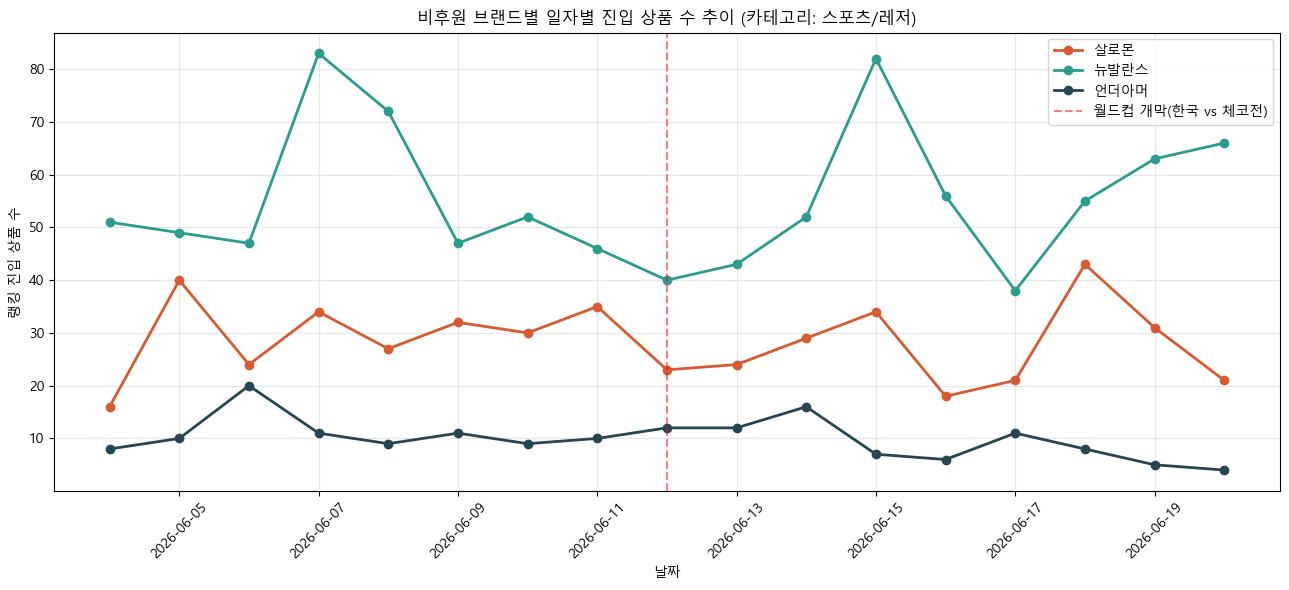


=== 비후원 브랜드별 월드컵 전후 평균 순위 변화 (카테고리: 스포츠/레저) ===

[살로몬]  460.3위 → 449.2위  (+11.1위 변화)
[뉴발란스]  465.7위 → 478.6위  (-12.9위 변화)
[언더아머]  534.6위 → 508.6위  (+26.0위 변화)

=== 비후원 브랜드별 월드컵 전후 일평균 랭킹 진입 상품 수 변화 (카테고리: 스포츠/레저) ===

[살로몬]  29.8개/일 → 27.1개/일  (-2.6개)
[뉴발란스]  55.9개/일 → 55.0개/일  (-0.9개)
[언더아머]  11.0개/일 → 9.0개/일  (-2.0개)


In [13]:
비후원_df = df_target[df_target['그룹'] == '비후원'].copy()

비후원_brand_daily = 비후원_df.groupby(['수집날짜', '브랜드'])['순위'].mean().reset_index()

plt.figure(figsize=(13, 6))

colors_b = {'살로몬': '#D85A30', '뉴발란스': '#2A9D8F', '언더아머': '#264653'}
for brand in ['살로몬', '뉴발란스', '언더아머']:
    brand_data = 비후원_brand_daily[비후원_brand_daily['브랜드'] == brand]
    plt.plot(brand_data['수집날짜'], brand_data['순위'], 
             marker='o', label=brand, color=colors_b[brand], linewidth=2)

plt.axvline(x=pd.to_datetime('2026-06-12'), color='gray', linestyle='--', alpha=0.5, label='월드컵 개막(한국 vs 체코전)')

plt.gca().invert_yaxis()
plt.xlabel('날짜')
plt.ylabel('평균 순위')
plt.title('비후원 브랜드별 일자별 평균 순위 추이 (카테고리: 스포츠/레저)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

비후원_count_daily = 비후원_df.groupby(['수집날짜', '브랜드']).size().reset_index(name='상품수')

plt.figure(figsize=(13, 6))
for brand in ['살로몬', '뉴발란스', '언더아머']:
    brand_data = 비후원_count_daily[비후원_count_daily['브랜드'] == brand]
    plt.plot(brand_data['수집날짜'], brand_data['상품수'], 
             marker='o', label=brand, color=colors_b[brand], linewidth=2)

plt.axvline(x=pd.to_datetime('2026-06-12'), color='red', linestyle='--', alpha=0.5, label='월드컵 개막(한국 vs 체코전)')

plt.xlabel('날짜')
plt.ylabel('랭킹 진입 상품 수')
plt.title('비후원 브랜드별 일자별 진입 상품 수 추이 (카테고리: 스포츠/레저)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n=== 비후원 브랜드별 월드컵 전후 평균 순위 변화 (카테고리: 스포츠/레저) ===\n")
for brand in ['살로몬', '뉴발란스', '언더아머']:
    before = 비후원_df[(비후원_df['브랜드'] == brand) & 
                     (비후원_df['수집날짜'] < pd.to_datetime('2026-06-12'))]['순위'].mean()
    after = 비후원_df[(비후원_df['브랜드'] == brand) & 
                    (비후원_df['수집날짜'] >= pd.to_datetime('2026-06-12'))]['순위'].mean()
    
    print(f"[{brand}]  {before:.1f}위 → {after:.1f}위  ({before - after:+.1f}위 변화)")

print("\n=== 비후원 브랜드별 월드컵 전후 일평균 랭킹 진입 상품 수 변화 (카테고리: 스포츠/레저) ===\n")
for brand in ['살로몬', '뉴발란스', '언더아머']:
    before_data = 비후원_df[(비후원_df['브랜드'] == brand) & 
                          (비후원_df['수집날짜'] < pd.to_datetime('2026-06-12'))]
    after_data = 비후원_df[(비후원_df['브랜드'] == brand) & 
                         (비후원_df['수집날짜'] >= pd.to_datetime('2026-06-12'))]
    
    before_days = before_data['수집날짜'].nunique()
    after_days = after_data['수집날짜'].nunique()
    
    before_avg = len(before_data) / before_days
    after_avg = len(after_data) / after_days
    
    print(f"[{brand}]  {before_avg:.1f}개/일 → {after_avg:.1f}개/일  ({after_avg - before_avg:+.1f}개)")

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from supabase import create_client

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

url = "https://wrprmiiyzwoulpaurthb.supabase.co"
key = "sb_publishable_etOa8Ca_IDmBeO_-YNb3OA_U3OmhRTZ"
supabase = create_client(url, key)



all_data = []
page_size = 1000
offset = 0

while True:
    response = supabase.table("ranking_by_category") \
        .select("*") \
        .eq("카테고리", "스포츠/레저") \
        .range(offset, offset + page_size - 1) \
        .execute()
    if not response.data:
        break
    all_data.extend(response.data)
    offset += page_size

df = pd.DataFrame(all_data)
df['수집날짜'] = pd.to_datetime(df['수집날짜'])


후원_브랜드 = ['나이키', '아디다스', '푸마']
df_후원 = df[df['브랜드'].isin(후원_브랜드)].copy()

print("총 행 수:", len(df_후원))
print("\n날짜별 행 수:")
print(df_후원['수집날짜'].dt.date.value_counts().sort_index())

총 행 수: 2092

날짜별 행 수:
수집날짜
2026-06-04    111
2026-06-05    151
2026-06-06     90
2026-06-07    135
2026-06-08    118
2026-06-09    127
2026-06-10    123
2026-06-11    124
2026-06-12    131
2026-06-13    131
2026-06-14    104
2026-06-15    138
2026-06-16    123
2026-06-17    117
2026-06-18    115
2026-06-19    136
2026-06-20    118
Name: count, dtype: int64


In [15]:
result = df_후원.groupby('브랜드').agg(
    진입_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean'),
    중앙값_순위=('순위', 'median'),
    최고_순위=('순위', 'min'),
).reset_index()

후원국수 = {'나이키': 12, '아디다스': 14, '푸마': 11}
result['후원_국가_수'] = result['브랜드'].map(후원국수)

result = result[['브랜드', '후원_국가_수', '진입_상품_수', '평균_순위', '중앙값_순위', '최고_순위']]
result = result.sort_values('진입_상품_수', ascending=False)

print(result.to_string(index=False))

 브랜드  후원_국가_수  진입_상품_수      평균_순위  중앙값_순위  최고_순위
아디다스       14     1570 536.181529   590.5      1
 나이키       12      463 482.388769   506.0      1
  푸마       11       59 591.033898   692.0     22


In [16]:
df_월드컵 = df_후원[df_후원['수집날짜'] >= pd.to_datetime('2026-06-12')].copy()

result_wc = df_월드컵.groupby('브랜드').agg(
    진입_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean'),
    중앙값_순위=('순위', 'median'),
    최고_순위=('순위', 'min'),
).reset_index()

후원국수 = {'나이키': 12, '아디다스': 14, '푸마': 11}
result_wc['후원_국가_수'] = result_wc['브랜드'].map(후원국수)

result_wc = result_wc[['브랜드', '후원_국가_수', '진입_상품_수', '평균_순위', '중앙값_순위', '최고_순위']]
result_wc = result_wc.sort_values('진입_상품_수', ascending=False)

print("=== 월드컵 기간(6/12 ~ 6/19) 후원 브랜드 비교 ===\n")
print(result_wc.to_string(index=False))

=== 월드컵 기간(6/12 ~ 6/19) 후원 브랜드 비교 ===

 브랜드  후원_국가_수  진입_상품_수      평균_순위  중앙값_순위  최고_순위
아디다스       14      843 489.180308   472.0      1
 나이키       12      240 436.970833   440.5      1
  푸마       11       30 486.533333   390.0     22


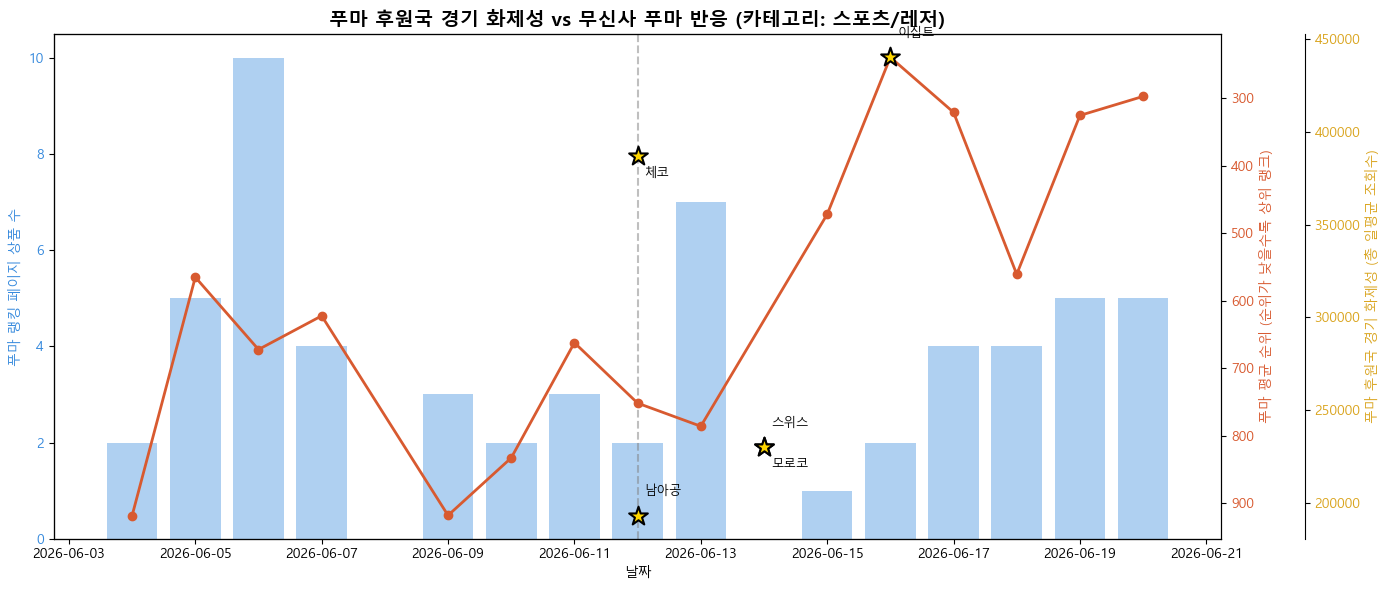


=== 푸마 후원국 경기 + 다음날 푸마 진입 변화 (카테고리: 스포츠/레저) ===

[06/12 멕시코 vs 남아공] 화제성: 193,334
  진입 상품: 2개 → 7개  (+5개)
  평균 순위: 751.5위 → 785.7위  (-34.2위)

[06/12 한국 vs 체코] 화제성: 386,667
  진입 상품: 2개 → 7개  (+5개)
  평균 순위: 751.5위 → 785.7위  (-34.2위)

[06/16 벨기에 vs 이집트] 화제성: 440,000
  진입 상품: 2개 → 4개  (+2개)
  평균 순위: 239.5위 → 321.0위  (-81.5위)



In [17]:
푸마_경기 = pd.DataFrame([
    {'경기일': '2026-06-12', '경기': '멕시코 vs 남아공',     '푸마_국가': '남아공',     '결과': '패', 'KBS_일평균': 56667,  'JTBC_일평균': 136667},
    {'경기일': '2026-06-12', '경기': '한국 vs 체코',         '푸마_국가': '체코',       '결과': '패', 'KBS_일평균': 80000,  'JTBC_일평균': 306667},
    {'경기일': '2026-06-14', '경기': '카타르 vs 스위스',     '푸마_국가': '스위스',     '결과': '무', 'KBS_일평균': 75000,  'JTBC_일평균': 155000},
    {'경기일': '2026-06-14', '경기': '브라질 vs 모로코',     '푸마_국가': '모로코',     '결과': '무', 'KBS_일평균': 110000, 'JTBC_일평균': 120000},
    {'경기일': '2026-06-16', '경기': '벨기에 vs 이집트',     '푸마_국가': '이집트',     '결과': '무', 'KBS_일평균': 275000, 'JTBC_일평균': 165000},
])
푸마_경기['경기일'] = pd.to_datetime(푸마_경기['경기일'])
푸마_경기['총_조회수'] = 푸마_경기['KBS_일평균'] + 푸마_경기['JTBC_일평균']


푸마_df = df_후원[df_후원['브랜드'] == '푸마'].copy()
푸마_일별 = 푸마_df.groupby('수집날짜').agg(
    랭킹_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean')
).reset_index()


fig, ax1 = plt.subplots(figsize=(14, 6))


ax1.bar(푸마_일별['수집날짜'], 푸마_일별['랭킹_상품_수'], 
        alpha=0.4, color='#378ADD', label='푸마 랭킹 페이지 상품 수')
ax1.set_xlabel('날짜')
ax1.set_ylabel('푸마 랭킹 페이지 상품 수', color='#378ADD')
ax1.tick_params(axis='y', labelcolor='#378ADD')


ax2 = ax1.twinx()
ax2.plot(푸마_일별['수집날짜'], 푸마_일별['평균_순위'], 
         marker='o', color='#D85A30', linewidth=2, label='푸마 평균 순위')
ax2.invert_yaxis()
ax2.set_ylabel('푸마 평균 순위 (순위가 낮을수록 상위 랭크)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')


ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.scatter(푸마_경기['경기일'], 푸마_경기['총_조회수'], 
            s=200, marker='*', color='gold', edgecolors='black', linewidths=1.5, 
            label='푸마 후원국 경기 화제성', zorder=5)
ax3.set_ylabel('푸마 후원국 경기 화제성 (총 일평균 조회수)', color='goldenrod')
ax3.tick_params(axis='y', labelcolor='goldenrod')


for i, (_, row) in enumerate(푸마_경기.iterrows()):
    y_offset = 15 if i % 2 == 0 else -15
    ax3.annotate(row['푸마_국가'], 
                xy=(row['경기일'], row['총_조회수']),
                xytext=(5, y_offset), textcoords='offset points',
                fontsize=9, color='black')

ax1.axvline(x=pd.to_datetime('2026-06-12'), color='gray', linestyle='--', alpha=0.5)

plt.title('푸마 후원국 경기 화제성 vs 무신사 푸마 반응 (카테고리: 스포츠/레저)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("\n=== 푸마 후원국 경기 + 다음날 푸마 진입 변화 (카테고리: 스포츠/레저) ===\n")
for _, 경기 in 푸마_경기.iterrows():
    경기일 = 경기['경기일']
    다음날 = 경기일 + pd.Timedelta(days=1)
    
    당일_데이터 = 푸마_일별[푸마_일별['수집날짜'] == 경기일]
    다음날_데이터 = 푸마_일별[푸마_일별['수집날짜'] == 다음날]
    
    if len(당일_데이터) > 0 and len(다음날_데이터) > 0:
        당일_상품수 = 당일_데이터['랭킹_상품_수'].values[0]
        다음날_상품수 = 다음날_데이터['랭킹_상품_수'].values[0]
        당일_순위 = 당일_데이터['평균_순위'].values[0]
        다음날_순위 = 다음날_데이터['평균_순위'].values[0]
        
        print(f"[{경기['경기일'].strftime('%m/%d')} {경기['경기']}] 화제성: {경기['총_조회수']:,}")
        print(f"  진입 상품: {당일_상품수}개 → {다음날_상품수}개  ({다음날_상품수 - 당일_상품수:+d}개)")
        print(f"  평균 순위: {당일_순위:.1f}위 → {다음날_순위:.1f}위  ({당일_순위 - 다음날_순위:+.1f}위)")
        print()

In [18]:
나이키_경기 = pd.DataFrame([
    {'경기일': '2026-06-12', '경기': '한국 vs 체코',          '후원국': '한국',       '결과': '승', 'KBS_일평균': 80000,  'JTBC_일평균': 306667},
    {'경기일': '2026-06-13', '경기': '캐나다 vs 보스니아',     '후원국': '캐나다',     '결과': '무', 'KBS_일평균': 78000,  'JTBC_일평균': 62000},
    {'경기일': '2026-06-13', '경기': '미국 vs 파라과이',       '후원국': '미국',       '결과': '승', 'KBS_일평균': 30000,  'JTBC_일평균': 98000},
    {'경기일': '2026-06-14', '경기': '브라질 vs 모로코',       '후원국': '브라질',     '결과': '무', 'KBS_일평균': 110000, 'JTBC_일평균': 120000},
    {'경기일': '2026-06-14', '경기': '호주 vs 튀르키예',       '후원국': '호주/튀르키예', '결과': '승', 'KBS_일평균': 102500, 'JTBC_일평균': 97500},
    {'경기일': '2026-06-15', '경기': '네덜란드 vs 일본',       '후원국': '네덜란드',   '결과': '무', 'KBS_일평균': 380000, 'JTBC_일평균': 93333},
])

아디다스_경기 = pd.DataFrame([
    {'경기일': '2026-06-12', '경기': '멕시코 vs 남아공',       '후원국': '멕시코',     '결과': '승', 'KBS_일평균': 56667,  'JTBC_일평균': 136667},
    {'경기일': '2026-06-14', '경기': '아이티 vs 스코틀랜드',   '후원국': '스코틀랜드', '결과': '승', 'KBS_일평균': 67500,  'JTBC_일평균': 35000},
    {'경기일': '2026-06-15', '경기': '독일 vs 퀴라소',         '후원국': '독일/퀴라소', '결과': '승', 'KBS_일평균': 210000, 'JTBC_일평균': 103333},
    {'경기일': '2026-06-15', '경기': '네덜란드 vs 일본',       '후원국': '일본',       '결과': '무', 'KBS_일평균': 380000, 'JTBC_일평균': 93333},
    {'경기일': '2026-06-15', '경기': '스웨덴 vs 튀니지',       '후원국': '스웨덴',     '결과': '승', 'KBS_일평균': 190000, 'JTBC_일평균': 40000},
    {'경기일': '2026-06-16', '경기': '스페인 vs 카보베르데',   '후원국': '스페인',     '결과': '무', 'KBS_일평균': 385000, 'JTBC_일평균': 200000},
    {'경기일': '2026-06-16', '경기': '벨기에 vs 이집트',       '후원국': '벨기에',     '결과': '무', 'KBS_일평균': 275000, 'JTBC_일평균': 165000},
    {'경기일': '2026-06-16', '경기': '사우디 vs 우루과이',     '후원국': '사우디/우루과이', '결과': '무', 'KBS_일평균': 275000, 'JTBC_일평균': 115000},
])


for df_경기 in [나이키_경기, 아디다스_경기]:
    df_경기['경기일'] = pd.to_datetime(df_경기['경기일'])
    df_경기['총_조회수'] = df_경기['KBS_일평균'] + df_경기['JTBC_일평균']


나이키_일별 = df_후원[df_후원['브랜드'] == '나이키'].groupby('수집날짜').agg(
    랭킹_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean')
).reset_index()

아디다스_일별 = df_후원[df_후원['브랜드'] == '아디다스'].groupby('수집날짜').agg(
    진입_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean')
).reset_index()

print("나이키 일별:")
print(나이키_일별.to_string(index=False))
print("\n아디다스 일별:")
print(아디다스_일별.to_string(index=False))

나이키 일별:
      수집날짜  랭킹_상품_수      평균_순위
2026-06-04       21 541.380952
2026-06-05       35 540.800000
2026-06-06       17 442.588235
2026-06-07       29 607.482759
2026-06-08       38 512.894737
2026-06-09       22 556.681818
2026-06-10       32 527.593750
2026-06-11       29 497.068966
2026-06-12       26 495.346154
2026-06-13       29 422.172414
2026-06-14       23 511.434783
2026-06-15       32 450.781250
2026-06-16       29 416.758621
2026-06-17       19 370.526316
2026-06-18       29 425.344828
2026-06-19       21 463.238095
2026-06-20       32 386.687500

아디다스 일별:
      수집날짜  진입_상품_수      평균_순위
2026-06-04       88 597.090909
2026-06-05      111 650.657658
2026-06-06       63 438.333333
2026-06-07      102 643.882353
2026-06-08       80 627.737500
2026-06-09      102 551.843137
2026-06-10       89 531.179775
2026-06-11       92 625.934783
2026-06-12      103 512.669903
2026-06-13       95 574.094737
2026-06-14       81 673.493827
2026-06-15      105 462.685714
2026-06-16       92 3

In [19]:
나이키_경기 = pd.DataFrame([
    {'경기일': '2026-06-12', '경기': '한국 vs 체코',          '후원국': '한국',       '결과': '승', 'KBS_일평균': 80000,  'JTBC_일평균': 306667},
    {'경기일': '2026-06-13', '경기': '캐나다 vs 보스니아',     '후원국': '캐나다',     '결과': '무', 'KBS_일평균': 78000,  'JTBC_일평균': 62000},
    {'경기일': '2026-06-13', '경기': '미국 vs 파라과이',       '후원국': '미국',       '결과': '승', 'KBS_일평균': 30000,  'JTBC_일평균': 98000},
    {'경기일': '2026-06-14', '경기': '브라질 vs 모로코',       '후원국': '브라질',     '결과': '무', 'KBS_일평균': 110000, 'JTBC_일평균': 120000},
    {'경기일': '2026-06-14', '경기': '호주 vs 튀르키예',       '후원국': '호주/튀르키예', '결과': '승', 'KBS_일평균': 102500, 'JTBC_일평균': 97500},
    {'경기일': '2026-06-15', '경기': '네덜란드 vs 일본',       '후원국': '네덜란드',   '결과': '무', 'KBS_일평균': 380000, 'JTBC_일평균': 93333},
])

아디다스_경기 = pd.DataFrame([
    {'경기일': '2026-06-12', '경기': '멕시코 vs 남아공',       '후원국': '멕시코',     '결과': '승', 'KBS_일평균': 56667,  'JTBC_일평균': 136667},
    {'경기일': '2026-06-14', '경기': '아이티 vs 스코틀랜드',   '후원국': '스코틀랜드', '결과': '승', 'KBS_일평균': 67500,  'JTBC_일평균': 35000},
    {'경기일': '2026-06-15', '경기': '독일 vs 퀴라소',         '후원국': '독일/퀴라소', '결과': '승', 'KBS_일평균': 210000, 'JTBC_일평균': 103333},
    {'경기일': '2026-06-15', '경기': '네덜란드 vs 일본',       '후원국': '일본',       '결과': '무', 'KBS_일평균': 380000, 'JTBC_일평균': 93333},
    {'경기일': '2026-06-15', '경기': '스웨덴 vs 튀니지',       '후원국': '스웨덴',     '결과': '승', 'KBS_일평균': 190000, 'JTBC_일평균': 40000},
    {'경기일': '2026-06-16', '경기': '스페인 vs 카보베르데',   '후원국': '스페인',     '결과': '무', 'KBS_일평균': 385000, 'JTBC_일평균': 200000},
    {'경기일': '2026-06-16', '경기': '벨기에 vs 이집트',       '후원국': '벨기에',     '결과': '무', 'KBS_일평균': 275000, 'JTBC_일평균': 165000},
    {'경기일': '2026-06-16', '경기': '사우디 vs 우루과이',     '후원국': '사우디/우루과이', '결과': '무', 'KBS_일평균': 275000, 'JTBC_일평균': 115000},
])


푸마_경기 = pd.DataFrame([
    {'경기일': '2026-06-12', '경기': '멕시코 vs 남아공',     '후원국': '남아공',     '결과': '패', 'KBS_일평균': 56667,  'JTBC_일평균': 136667},
    {'경기일': '2026-06-12', '경기': '한국 vs 체코',         '후원국': '체코',       '결과': '패', 'KBS_일평균': 80000,  'JTBC_일평균': 306667},
    {'경기일': '2026-06-14', '경기': '카타르 vs 스위스',     '후원국': '스위스',     '결과': '무', 'KBS_일평균': 75000,  'JTBC_일평균': 155000},
    {'경기일': '2026-06-14', '경기': '브라질 vs 모로코',     '후원국': '모로코',     '결과': '무', 'KBS_일평균': 110000, 'JTBC_일평균': 120000},
    {'경기일': '2026-06-16', '경기': '벨기에 vs 이집트',     '후원국': '이집트',     '결과': '무', 'KBS_일평균': 275000, 'JTBC_일평균': 165000},
])


for df_경기 in [나이키_경기, 아디다스_경기, 푸마_경기]:
    df_경기['경기일'] = pd.to_datetime(df_경기['경기일'])
    df_경기['총_조회수'] = df_경기['KBS_일평균'] + df_경기['JTBC_일평균']


나이키_일별 = df_후원[df_후원['브랜드'] == '나이키'].groupby('수집날짜').agg(
    랭킹_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean')
).reset_index()

아디다스_일별 = df_후원[df_후원['브랜드'] == '아디다스'].groupby('수집날짜').agg(
    랭킹_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean')
).reset_index()

푸마_일별 = df_후원[df_후원['브랜드'] == '푸마'].groupby('수집날짜').agg(
    랭킹_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean')
).reset_index()

print("나이키 일별:")
print(나이키_일별.to_string(index=False))
print("\n아디다스 일별:")
print(아디다스_일별.to_string(index=False))

나이키 일별:
      수집날짜  랭킹_상품_수      평균_순위
2026-06-04       21 541.380952
2026-06-05       35 540.800000
2026-06-06       17 442.588235
2026-06-07       29 607.482759
2026-06-08       38 512.894737
2026-06-09       22 556.681818
2026-06-10       32 527.593750
2026-06-11       29 497.068966
2026-06-12       26 495.346154
2026-06-13       29 422.172414
2026-06-14       23 511.434783
2026-06-15       32 450.781250
2026-06-16       29 416.758621
2026-06-17       19 370.526316
2026-06-18       29 425.344828
2026-06-19       21 463.238095
2026-06-20       32 386.687500

아디다스 일별:
      수집날짜  랭킹_상품_수      평균_순위
2026-06-04       88 597.090909
2026-06-05      111 650.657658
2026-06-06       63 438.333333
2026-06-07      102 643.882353
2026-06-08       80 627.737500
2026-06-09      102 551.843137
2026-06-10       89 531.179775
2026-06-11       92 625.934783
2026-06-12      103 512.669903
2026-06-13       95 574.094737
2026-06-14       81 673.493827
2026-06-15      105 462.685714
2026-06-16       92 3

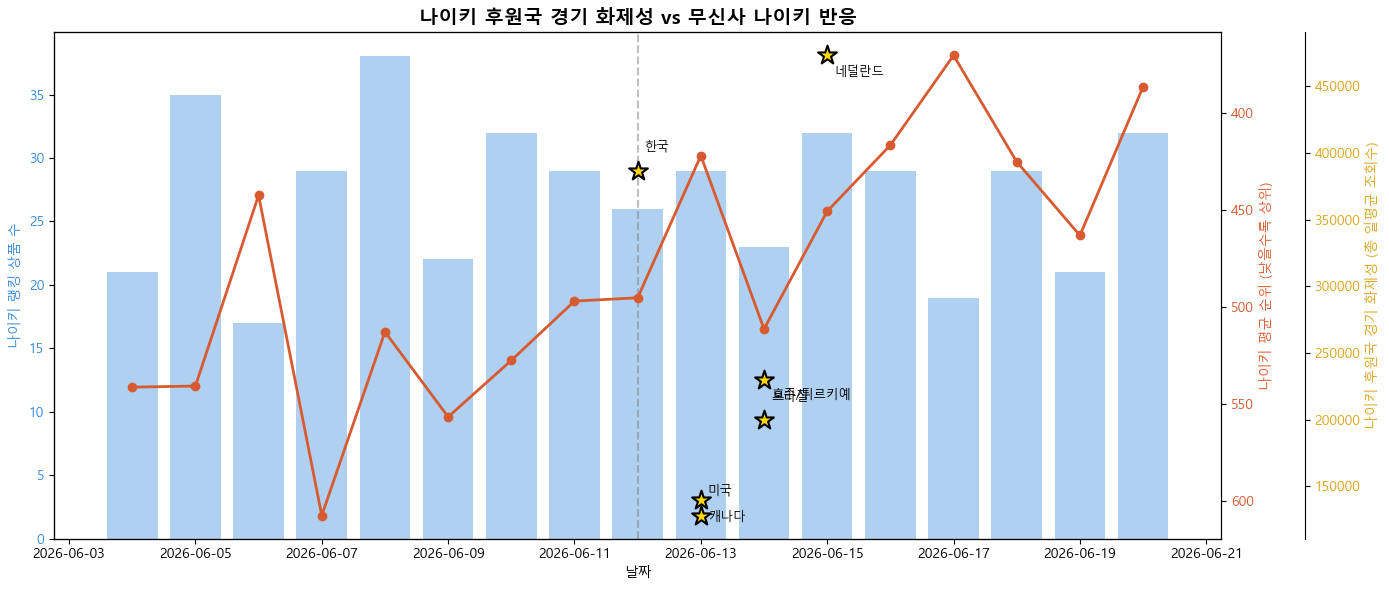

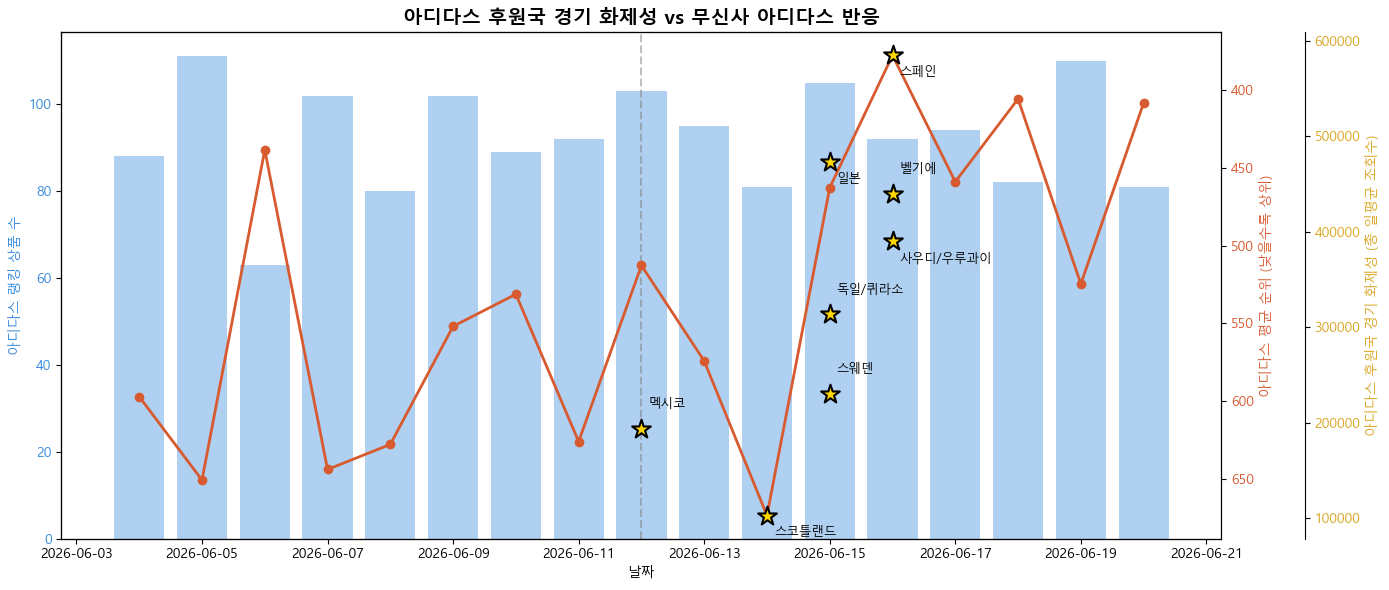

In [20]:
# 나이키 시각화
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(나이키_일별['수집날짜'], 나이키_일별['랭킹_상품_수'], 
        alpha=0.4, color='#378ADD', label='나이키 랭킹 상품 수')
ax1.set_xlabel('날짜')
ax1.set_ylabel('나이키 랭킹 상품 수', color='#378ADD')
ax1.tick_params(axis='y', labelcolor='#378ADD')

ax2 = ax1.twinx()
ax2.plot(나이키_일별['수집날짜'], 나이키_일별['평균_순위'], 
         marker='o', color='#D85A30', linewidth=2, label='나이키 평균 순위')
ax2.invert_yaxis()
ax2.set_ylabel('나이키 평균 순위 (낮을수록 상위)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.scatter(나이키_경기['경기일'], 나이키_경기['총_조회수'], 
            s=200, marker='*', color='gold', edgecolors='black', linewidths=1.5, 
            label='나이키 후원국 경기 화제성', zorder=5)
ax3.set_ylabel('나이키 후원국 경기 화제성 (총 일평균 조회수)', color='goldenrod')
ax3.tick_params(axis='y', labelcolor='goldenrod')


for i, (_, row) in enumerate(나이키_경기.iterrows()):
    y_offset = 15 if i % 2 == 0 else -15
    ax3.annotate(row['후원국'], 
                xy=(row['경기일'], row['총_조회수']),
                xytext=(5, y_offset), textcoords='offset points',
                fontsize=9, color='black')

ax1.axvline(x=pd.to_datetime('2026-06-12'), color='gray', linestyle='--', alpha=0.5)
plt.title('나이키 후원국 경기 화제성 vs 무신사 나이키 반응', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 아디다스 시각화
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(아디다스_일별['수집날짜'], 아디다스_일별['랭킹_상품_수'], 
        alpha=0.4, color='#378ADD', label='아디다스 랭킹 상품 수')
ax1.set_xlabel('날짜')
ax1.set_ylabel('아디다스 랭킹 상품 수', color='#378ADD')
ax1.tick_params(axis='y', labelcolor='#378ADD')

ax2 = ax1.twinx()
ax2.plot(아디다스_일별['수집날짜'], 아디다스_일별['평균_순위'], 
         marker='o', color='#D85A30', linewidth=2, label='아디다스 평균 순위')
ax2.invert_yaxis()
ax2.set_ylabel('아디다스 평균 순위 (낮을수록 상위)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.scatter(아디다스_경기['경기일'], 아디다스_경기['총_조회수'], 
            s=200, marker='*', color='gold', edgecolors='black', linewidths=1.5, 
            label='아디다스 후원국 경기 화제성', zorder=5)
ax3.set_ylabel('아디다스 후원국 경기 화제성 (총 일평균 조회수)', color='goldenrod')
ax3.tick_params(axis='y', labelcolor='goldenrod')


for i, (_, row) in enumerate(아디다스_경기.iterrows()):
    y_offset = 15 if i % 2 == 0 else -15
    ax3.annotate(row['후원국'], 
                xy=(row['경기일'], row['총_조회수']),
                xytext=(5, y_offset), textcoords='offset points',
                fontsize=9, color='black')

ax1.axvline(x=pd.to_datetime('2026-06-12'), color='gray', linestyle='--', alpha=0.5)
plt.title('아디다스 후원국 경기 화제성 vs 무신사 아디다스 반응', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
print("=== 후원사별 후원국 경기 평균 화제성 ===\n")
print(f"나이키 평균 화제성: {나이키_경기['총_조회수'].mean():,.0f}")
print(f"아디다스 평균 화제성: {아디다스_경기['총_조회수'].mean():,.0f}")
print(f"푸마 평균 화제성: {푸마_경기['총_조회수'].mean():,.0f}")

=== 후원사별 후원국 경기 평균 화제성 ===

나이키 평균 화제성: 259,667
아디다스 평균 화제성: 340,938
푸마 평균 화제성: 296,000


In [22]:
#가설 11 — 월드컵 효과의 상품 유형 분석

df_월드컵 = df_후원[df_후원['수집날짜'] >= pd.to_datetime('2026-06-12')].copy()

for brand in ['나이키', '아디다스', '푸마']:
    print(f"\n=== {brand} 상위 진입 상품 (월드컵 기간) ===")
    상품_샘플 = df_월드컵[df_월드컵['브랜드'] == brand].sort_values('순위').head(15)
    for _, row in 상품_샘플.iterrows():
        print(f"  {row['순위']:>4}위 ({row['수집날짜'].strftime('%m/%d')}) {row['상품명'][:60]}")


=== 나이키 상위 진입 상품 (월드컵 기간) ===
     1위 (06/20) 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 골드 / 
     1위 (06/12) 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 골드 / 
     1위 (06/13) [마킹] 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 
     1위 (06/14) 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 골드 / 
     1위 (06/15) 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 골드 / 
     2위 (06/13) 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 골드 / 
     3위 (06/12) [마킹] 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 
     4위 (06/14) [마킹] 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 
     4위 (06/18) 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 골드 / 
     5위 (06/17) 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 골드 / 
     5위 (06/19) 대한민국 2026 스타디움 홈 드라이 핏 축구 레플리카 저지 M - 글로벌 레드:블랙:화이트:클럽 골드 / 
     6위 (06/15) 인터 밀란 ACG 축구 티셔츠 M - 화이트 / IF0513-100
     6위 (06/20) 대한민국 2026 스타디움 어웨이 드라이 핏 축구 레플리카 저지 M - 스페이스 퍼플:애미시스

In [23]:
축구_키워드 = ['축구', '저지', '스타디움', '레플리카', 'FC', '풋볼', 'Jersey', '유니폼']

def is_축구(상품명):
    return any(키워드 in 상품명 for 키워드 in 축구_키워드)

df_후원['축구상품'] = df_후원['상품명'].apply(is_축구)

# 월드컵 전후 분류
df_후원['시기'] = df_후원['수집날짜'].apply(
    lambda x: '월드컵 전' if x < pd.to_datetime('2026-06-12') else '월드컵 후'
)

# 시기 × 브랜드 × 축구/비축구별 집계
result = df_후원.groupby(['시기', '브랜드', '축구상품']).agg(
    랭킹_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean')
).reset_index()

print(result.to_string(index=False))

   시기  브랜드  축구상품  랭킹_상품_수      평균_순위
월드컵 전  나이키 False      146 538.787671
월드컵 전  나이키  True       77 517.012987
월드컵 전 아디다스 False      551 568.344828
월드컵 전 아디다스  True      176 660.613636
월드컵 전   푸마 False       13 657.769231
월드컵 전   푸마  True       16 732.750000
월드컵 후  나이키 False      159 518.509434
월드컵 후  나이키  True       81 276.913580
월드컵 후 아디다스 False      677 486.184638
월드컵 후 아디다스  True      166 501.397590
월드컵 후   푸마 False       26 455.461538
월드컵 후   푸마  True        4 688.500000


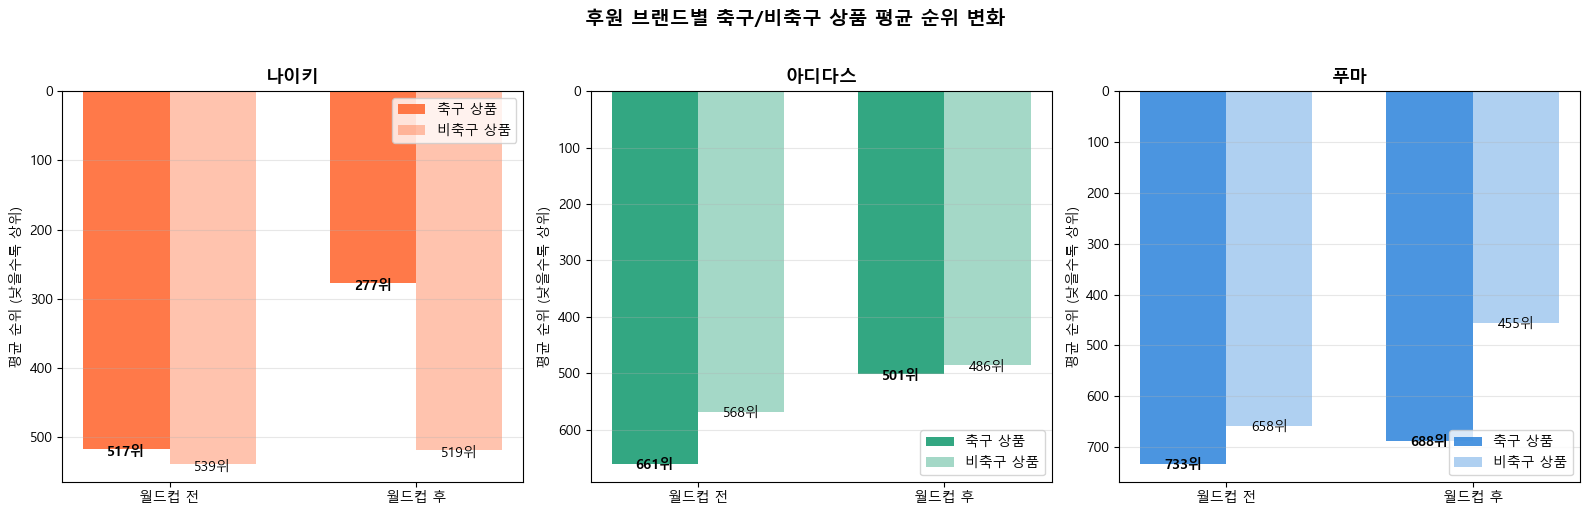

In [24]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

brands = ['나이키', '아디다스', '푸마']
colors = {'나이키': '#FF6B35', '아디다스': '#1D9E75', '푸마': '#378ADD'}

for idx, brand in enumerate(brands):
    ax = axes[idx]
    
    # 데이터 추출
    before_축구 = result[(result['브랜드'] == brand) & 
                       (result['시기'] == '월드컵 전') & 
                       (result['축구상품'] == True)]['평균_순위'].values
    before_비축구 = result[(result['브랜드'] == brand) & 
                         (result['시기'] == '월드컵 전') & 
                         (result['축구상품'] == False)]['평균_순위'].values
    after_축구 = result[(result['브랜드'] == brand) & 
                      (result['시기'] == '월드컵 후') & 
                      (result['축구상품'] == True)]['평균_순위'].values
    after_비축구 = result[(result['브랜드'] == brand) & 
                        (result['시기'] == '월드컵 후') & 
                        (result['축구상품'] == False)]['평균_순위'].values
    
    before_축구 = before_축구[0] if len(before_축구) > 0 else 0
    before_비축구 = before_비축구[0] if len(before_비축구) > 0 else 0
    after_축구 = after_축구[0] if len(after_축구) > 0 else 0
    after_비축구 = after_비축구[0] if len(after_비축구) > 0 else 0
    
    x = np.arange(2)
    width = 0.35
    
    bars1 = ax.bar(x - width/2, [before_축구, after_축구], width, 
                   label='축구 상품', color=colors[brand], alpha=0.9)
    bars2 = ax.bar(x + width/2, [before_비축구, after_비축구], width, 
                   label='비축구 상품', color=colors[brand], alpha=0.4)
    
    ax.set_xticks(x)
    ax.set_xticklabels(['월드컵 전', '월드컵 후'])
    ax.set_title(brand, fontsize=13, fontweight='bold')
    ax.set_ylabel('평균 순위 (낮을수록 상위)')
    ax.invert_yaxis()
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    
    # 값 표시
    for bar, val in zip(bars1, [before_축구, after_축구]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 10, f'{val:.0f}위',
                ha='center', fontsize=10, fontweight='bold')
    for bar, val in zip(bars2, [before_비축구, after_비축구]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 10, f'{val:.0f}위',
                ha='center', fontsize=10)

plt.suptitle('후원 브랜드별 축구/비축구 상품 평균 순위 변화', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
한국_경기 = pd.DataFrame([
    {'경기일': '2026-06-12', '경기': '한국 vs 체코',     '상대': '체코',   '결과': '승', '한국_득점': 2, '상대_득점': 1, 'KBS_일평균': 80000, 'JTBC_일평균': 306667},
    {'경기일': '2026-06-19', '경기': '멕시코 vs 한국',   '상대': '멕시코', '결과': None, '한국_득점': None, '상대_득점': None, 'KBS_일평균': None, 'JTBC_일평균': None},
    {'경기일': '2026-06-25', '경기': '남아공 vs 한국',   '상대': '남아공', '결과': None, '한국_득점': None, '상대_득점': None, 'KBS_일평균': None, 'JTBC_일평균': None},
])
한국_경기['경기일'] = pd.to_datetime(한국_경기['경기일'])

print(한국_경기)

         경기일         경기   상대   결과  한국_득점  상대_득점  KBS_일평균  JTBC_일평균
0 2026-06-12   한국 vs 체코   체코    승    2.0    1.0  80000.0  306667.0
1 2026-06-19  멕시코 vs 한국  멕시코  NaN    NaN    NaN      NaN       NaN
2 2026-06-25  남아공 vs 한국  남아공  NaN    NaN    NaN      NaN       NaN


In [26]:
# === 가설 3: 한국 경기 D-1 ~ D+2 효과 ===
# 가설: "경기를 기점으로 며칠까지 무신사 순위 변동이 지속되는가"

print("=== 가설 3: 한국 경기 전후 4일간 변동 추이 ===\n")

for _, 경기 in 한국_경기.iterrows():
    경기일 = 경기['경기일']
    
    print(f"\n[{경기['경기'].strip()}] ({경기일.strftime('%m/%d')})")
    
    # D-1, D-day, D+1, D+2 데이터 수집
    구간 = {
        'D-1 (전날)':     경기일 - pd.Timedelta(days=1),
        'D-day (당일)':   경기일,
        'D+1 (다음날)':   경기일 + pd.Timedelta(days=1),
        'D+2 (이틀 후)':  경기일 + pd.Timedelta(days=2),
    }
    
    이전_순위 = None
    for 라벨, 날짜 in 구간.items():
        평균_순위 = df_target[(df_target['그룹'] == '후원') & 
                            (df_target['수집날짜'] == 날짜)]['순위'].mean()
        
        if pd.isna(평균_순위):
            print(f"  {라벨} ({날짜.strftime('%m/%d')}): 데이터 없음")
            이전_순위 = None
            continue
        
        if 이전_순위 is not None:
            변동 = 이전_순위 - 평균_순위
            print(f"  {라벨} ({날짜.strftime('%m/%d')}): 평균 순위 {평균_순위:.1f}위  (전일 대비 {변동:+.1f}위)")
        else:
            print(f"  {라벨} ({날짜.strftime('%m/%d')}): 평균 순위 {평균_순위:.1f}위  (기준점)")
        
        이전_순위 = 평균_순위

=== 가설 3: 한국 경기 전후 4일간 변동 추이 ===


[한국 vs 체코] (06/12)
  D-1 (전날) (06/11): 평균 순위 596.7위  (기준점)
  D-day (당일) (06/12): 평균 순위 512.9위  (전일 대비 +83.8위)
  D+1 (다음날) (06/13): 평균 순위 551.8위  (전일 대비 -38.9위)
  D+2 (이틀 후) (06/14): 평균 순위 637.7위  (전일 대비 -85.9위)

[멕시코 vs 한국] (06/19)
  D-1 (전날) (06/18): 평균 순위 416.0위  (기준점)
  D-day (당일) (06/19): 평균 순위 507.8위  (전일 대비 -91.8위)
  D+1 (다음날) (06/20): 평균 순위 397.7위  (전일 대비 +110.1위)
  D+2 (이틀 후) (06/21): 데이터 없음

[남아공 vs 한국] (06/25)
  D-1 (전날) (06/24): 데이터 없음
  D-day (당일) (06/25): 데이터 없음
  D+1 (다음날) (06/26): 데이터 없음
  D+2 (이틀 후) (06/27): 데이터 없음


In [27]:
# === 가설 5: 한국 경기 다음날 나이키(한국 후원사) 효과 ===
# 가설: "한국 경기 다음날 나이키가 다른 후원 브랜드보다 더 오른다"

print("=== 가설 5: 한국 경기 D-1 ~ D+2 브랜드별 변동 ===\n")

for _, 경기 in 한국_경기.iterrows():
    경기일 = 경기['경기일']
    
    print(f"\n[{경기['경기'].strip()}] ({경기일.strftime('%m/%d')})")
    
    구간 = {
        'D-1': 경기일 - pd.Timedelta(days=1),
        'D-day': 경기일,
        'D+1': 경기일 + pd.Timedelta(days=1),
        'D+2': 경기일 + pd.Timedelta(days=2),
    }
    
    for brand in ['나이키', '아디다스', '푸마']:
        print(f"  [{brand}]")
        이전_순위 = None
        for 라벨, 날짜 in 구간.items():
            평균_순위 = df_target[(df_target['브랜드'] == brand) & 
                                (df_target['수집날짜'] == 날짜)]['순위'].mean()
            
            if pd.isna(평균_순위):
                print(f"    {라벨} ({날짜.strftime('%m/%d')}): 데이터 없음")
                이전_순위 = None
                continue
            
            if 이전_순위 is not None:
                변동 = 이전_순위 - 평균_순위
                print(f"    {라벨} ({날짜.strftime('%m/%d')}): {평균_순위:.1f}위 ({변동:+.1f}위)")
            else:
                print(f"    {라벨} ({날짜.strftime('%m/%d')}): {평균_순위:.1f}위 (기준)")
            
            이전_순위 = 평균_순위

=== 가설 5: 한국 경기 D-1 ~ D+2 브랜드별 변동 ===


[한국 vs 체코] (06/12)
  [나이키]
    D-1 (06/11): 497.1위 (기준)
    D-day (06/12): 495.3위 (+1.7위)
    D+1 (06/13): 422.2위 (+73.2위)
    D+2 (06/14): 511.4위 (-89.3위)
  [아디다스]
    D-1 (06/11): 625.9위 (기준)
    D-day (06/12): 512.7위 (+113.3위)
    D+1 (06/13): 574.1위 (-61.4위)
    D+2 (06/14): 673.5위 (-99.4위)
  [푸마]
    D-1 (06/11): 662.0위 (기준)
    D-day (06/12): 751.5위 (-89.5위)
    D+1 (06/13): 785.7위 (-34.2위)
    D+2 (06/14): 데이터 없음

[멕시코 vs 한국] (06/19)
  [나이키]
    D-1 (06/18): 425.3위 (기준)
    D-day (06/19): 463.2위 (-37.9위)
    D+1 (06/20): 386.7위 (+76.6위)
    D+2 (06/21): 데이터 없음
  [아디다스]
    D-1 (06/18): 405.6위 (기준)
    D-day (06/19): 524.6위 (-119.0위)
    D+1 (06/20): 408.3위 (+116.3위)
    D+2 (06/21): 데이터 없음
  [푸마]
    D-1 (06/18): 560.8위 (기준)
    D-day (06/19): 325.6위 (+235.1위)
    D+1 (06/20): 297.4위 (+28.2위)
    D+2 (06/21): 데이터 없음

[남아공 vs 한국] (06/25)
  [나이키]
    D-1 (06/24): 데이터 없음
    D-day (06/25): 데이터 없음
    D+1 (06/26): 데이터 없음
    D+2 (06/27): 데이터 없

In [28]:
한국_경기 = pd.DataFrame([
    {'경기일': '2026-06-12', '경기': '한국 vs 체코',   '상대': '체코',   '결과': '승', '한국_득점': 2, '상대_득점': 1, 'KBS_일평균': 80000, 'JTBC_일평균': 306667},
    {'경기일': '2026-06-19', '경기': '멕시코 vs 한국', '상대': '멕시코', '결과': '패', '한국_득점': 0, '상대_득점': 1, 'KBS_일평균': None, 'JTBC_일평균': None},
    {'경기일': '2026-06-25', '경기': '남아공 vs 한국', '상대': '남아공', '결과': None, '한국_득점': None, '상대_득점': None, 'KBS_일평균': None, 'JTBC_일평균': None},
])
한국_경기['경기일'] = pd.to_datetime(한국_경기['경기일'])

print(한국_경기)

         경기일         경기   상대   결과  한국_득점  상대_득점  KBS_일평균  JTBC_일평균
0 2026-06-12   한국 vs 체코   체코    승    2.0    1.0  80000.0  306667.0
1 2026-06-19  멕시코 vs 한국  멕시코    패    0.0    1.0      NaN       NaN
2 2026-06-25  남아공 vs 한국  남아공  NaN    NaN    NaN      NaN       NaN


In [29]:
# === 가설 6: 한국 승패에 따른 후원 브랜드 반응 차이 ===

print("=== 가설 6: 한국 승패별 D+1 후원 브랜드 변동 ===\n")

승리_변동 = []
패배_변동 = []
무승부_변동 = []

for _, 경기 in 한국_경기.iterrows():
    if pd.isna(경기['결과']):
        print(f"[{경기['경기'].strip()}] 결과 미입력 - 건너뜀")
        continue
        
    경기일 = 경기['경기일']
    전날 = 경기일 - pd.Timedelta(days=1)
    다음날 = 경기일 + pd.Timedelta(days=1)
    
    전날_순위 = df_target[(df_target['그룹'] == '후원') & 
                        (df_target['수집날짜'] == 전날)]['순위'].mean()
    다음날_순위 = df_target[(df_target['그룹'] == '후원') & 
                          (df_target['수집날짜'] == 다음날)]['순위'].mean()
    
    if pd.isna(전날_순위) or pd.isna(다음날_순위):
        print(f"[{경기['경기'].strip()}] 결과: {경기['결과']}, 데이터 부족 - 건너뜀")
        continue
    
    변동 = 전날_순위 - 다음날_순위
    
    if 경기['결과'] == '승':
        승리_변동.append(변동)
    elif 경기['결과'] == '패':
        패배_변동.append(변동)
    elif 경기['결과'] == '무':
        무승부_변동.append(변동)
    
    print(f"[{경기['경기'].strip()}] 결과: {경기['결과']}, D+1 변동: {변동:+.1f}위")

print(f"\n=== 평균 변동 ===")
if 승리_변동:
    print(f"  승리 후 평균: {sum(승리_변동)/len(승리_변동):+.1f}위 (n={len(승리_변동)})")
if 패배_변동:
    print(f"  패배 후 평균: {sum(패배_변동)/len(패배_변동):+.1f}위 (n={len(패배_변동)})")
if 무승부_변동:
    print(f"  무승부 후 평균: {sum(무승부_변동)/len(무승부_변동):+.1f}위 (n={len(무승부_변동)})")

=== 가설 6: 한국 승패별 D+1 후원 브랜드 변동 ===

[한국 vs 체코] 결과: 승, D+1 변동: +44.9위
[멕시코 vs 한국] 결과: 패, D+1 변동: +18.3위
[남아공 vs 한국] 결과 미입력 - 건너뜀

=== 평균 변동 ===
  승리 후 평균: +44.9위 (n=1)
  패배 후 평균: +18.3위 (n=1)


In [30]:
# 전체 카테고리 데이터 (만든 함수 활용)
df_all = load_ranking_data()
print(f"전체 데이터: {len(df_all)}행")
print(f"\n카테고리별 데이터 수:")
print(df_all['카테고리'].value_counts())

불러온 데이터: 56934행
전체 데이터: 56934행

카테고리별 데이터 수:
카테고리
스포츠/레저     12496
상의         11474
바지         11209
아우터        10190
원피스/스커트    10190
신발          1375
Name: count, dtype: int64


In [31]:
# === 가설 7: 카테고리 후광 효과 ===
# 가설: "후원 브랜드가 스포츠/레저뿐 아니라 상의·바지·신발에서도 오르는가"

# 분석은 정상 데이터 구간만 (6/4~6/11, 6/18~6/19)
정상_월드컵_전 = (df_all['수집날짜'] >= pd.to_datetime('2026-06-04')) & \
              (df_all['수집날짜'] <= pd.to_datetime('2026-06-11'))
정상_월드컵_후 = df_all['수집날짜'] >= pd.to_datetime('2026-06-18')

df_정상 = df_all[정상_월드컵_전 | 정상_월드컵_후].copy()
df_정상['시기'] = df_정상['수집날짜'].apply(
    lambda x: '월드컵 전' if x < pd.to_datetime('2026-06-12') else '월드컵 후'
)

# 후원 브랜드만
후원_브랜드 = ['나이키', '아디다스', '푸마']
df_후원_전체 = df_정상[df_정상['브랜드'].isin(후원_브랜드)].copy()

# 시기 × 카테고리 × 브랜드별 평균 순위
print("=== 가설 7: 후원 브랜드 카테고리별 월드컵 전후 변화 ===\n")

result_h7 = df_후원_전체.groupby(['시기', '카테고리', '브랜드']).agg(
    랭킹_상품_수=('순위', 'count'),
    평균_순위=('순위', 'mean')
).reset_index()

# 변화량 계산용으로 피벗
for brand in 후원_브랜드:
    print(f"\n[{brand}]")
    brand_data = result_h7[result_h7['브랜드'] == brand]
    
    for category in ['스포츠/레저', '신발', '상의', '바지']:
        before = brand_data[(brand_data['카테고리'] == category) & 
                          (brand_data['시기'] == '월드컵 전')]['평균_순위'].values
        after = brand_data[(brand_data['카테고리'] == category) & 
                         (brand_data['시기'] == '월드컵 후')]['평균_순위'].values
        
        if len(before) > 0 and len(after) > 0:
            변동 = before[0] - after[0]
            print(f"  {category:>10}: {before[0]:.0f}위 → {after[0]:.0f}위 ({변동:+.0f}위)")
        else:
            print(f"  {category:>10}: 데이터 부족")

=== 가설 7: 후원 브랜드 카테고리별 월드컵 전후 변화 ===


[나이키]
      스포츠/레저: 531위 → 420위 (+111위)
          신발: 데이터 부족
          상의: 474위 → 453위 (+21위)
          바지: 411위 → 503위 (-92위)

[아디다스]
      스포츠/레저: 591위 → 454위 (+136위)
          신발: 데이터 부족
          상의: 460위 → 574위 (-114위)
          바지: 514위 → 531위 (-17위)

[푸마]
      스포츠/레저: 699위 → 383위 (+316위)
          신발: 데이터 부족
          상의: 944위 → 662위 (+282위)
          바지: 데이터 부족


In [32]:
# === 가설 8: 카테고리 교차 (제로섬 구조) ===
# 가설: "스포츠/레저 ↑ 일 때 다른 카테고리는 ↓ 인가"

# 후원 브랜드가 카테고리별로 어떻게 움직였는지 비교
# → 만약 스포츠/레저만 오르고 다른 카테고리는 내리면 → 제로섬
# → 모든 카테고리 다 오르면 → 후광 효과 (가설 7)

print("\n=== 가설 8: 후원 브랜드 카테고리별 변동 방향 비교 ===\n")

for brand in 후원_브랜드:
    brand_data = result_h7[result_h7['브랜드'] == brand]
    print(f"\n[{brand}]")
    
    오른_카테고리 = []
    내린_카테고리 = []
    
    for category in ['스포츠/레저', '신발', '상의', '바지']:
        before = brand_data[(brand_data['카테고리'] == category) & 
                          (brand_data['시기'] == '월드컵 전')]['평균_순위'].values
        after = brand_data[(brand_data['카테고리'] == category) & 
                         (brand_data['시기'] == '월드컵 후')]['평균_순위'].values
        
        if len(before) > 0 and len(after) > 0:
            변동 = before[0] - after[0]
            if 변동 > 0:
                오른_카테고리.append(f"{category}({변동:+.0f})")
            else:
                내린_카테고리.append(f"{category}({변동:+.0f})")
    
    print(f"  상승: {', '.join(오른_카테고리) if 오른_카테고리 else '없음'}")
    print(f"  하락: {', '.join(내린_카테고리) if 내린_카테고리 else '없음'}")
    
    if 오른_카테고리 and 내린_카테고리:
        print(f"  → 제로섬 구조 가능성")
    elif 오른_카테고리 and not 내린_카테고리:
        print(f"  → 전체 후광 효과")
    elif not 오른_카테고리 and 내린_카테고리:
        print(f"  → 전체 하락")


=== 가설 8: 후원 브랜드 카테고리별 변동 방향 비교 ===


[나이키]
  상승: 스포츠/레저(+111), 상의(+21)
  하락: 바지(-92)
  → 제로섬 구조 가능성

[아디다스]
  상승: 스포츠/레저(+136)
  하락: 상의(-114), 바지(-17)
  → 제로섬 구조 가능성

[푸마]
  상승: 스포츠/레저(+316), 상의(+282)
  하락: 없음
  → 전체 후광 효과


In [33]:
# === 가설 9: 브랜드 집중도 ===
# 가설: "월드컵 기간 상위권이 소수 인지도 브랜드로 집중되는가"

# 스포츠/레저 전체 데이터 (모든 브랜드)
df_sports = load_ranking_data(category='스포츠/레저')

# 정상 데이터 구간만 (6/4~6/11, 6/18 이후)
정상_전 = (df_sports['수집날짜'] >= pd.to_datetime('2026-06-04')) & \
         (df_sports['수집날짜'] <= pd.to_datetime('2026-06-11'))
정상_후 = df_sports['수집날짜'] >= pd.to_datetime('2026-06-18')
df_sports_정상 = df_sports[정상_전 | 정상_후].copy()
df_sports_정상['시기'] = df_sports_정상['수집날짜'].apply(
    lambda x: '월드컵 전' if x < pd.to_datetime('2026-06-12') else '월드컵 후'
)

print("=== 가설 9: 브랜드 집중도 분석 ===\n")

# 분석 1: TOP 100 안에 들어간 고유 브랜드 수
print("--- TOP 100 고유 브랜드 수 ---")
for 시기 in ['월드컵 전', '월드컵 후']:
    top100 = df_sports_정상[(df_sports_정상['시기'] == 시기) & 
                          (df_sports_정상['순위'] <= 100)]
    # 날짜별 평균 고유 브랜드 수
    날짜별_브랜드수 = top100.groupby('수집날짜')['브랜드'].nunique()
    평균_브랜드수 = 날짜별_브랜드수.mean()
    print(f"  {시기}: 일평균 {평균_브랜드수:.1f}개 브랜드")

# 분석 2: 상위 3개 브랜드 점유율
print("\n--- TOP 100 중 상위 3개 브랜드 점유율 ---")
for 시기 in ['월드컵 전', '월드컵 후']:
    top100 = df_sports_정상[(df_sports_정상['시기'] == 시기) & 
                          (df_sports_정상['순위'] <= 100)]
    브랜드_카운트 = top100['브랜드'].value_counts()
    top3_점유율 = 브랜드_카운트.head(3).sum() / len(top100) * 100
    print(f"  {시기}: 상위 3개 브랜드가 TOP 100의 {top3_점유율:.1f}% 차지")
    print(f"    → {', '.join(브랜드_카운트.head(3).index.tolist())}")

# 분석 3: HHI (허핀달 지수) - 시장 집중도 지표
print("\n--- 브랜드 집중도 지수 (HHI) ---")
for 시기 in ['월드컵 전', '월드컵 후']:
    top100 = df_sports_정상[(df_sports_정상['시기'] == 시기) & 
                          (df_sports_정상['순위'] <= 100)]
    점유율 = top100['브랜드'].value_counts() / len(top100)
    hhi = (점유율 ** 2).sum() * 10000
    print(f"  {시기}: HHI = {hhi:.0f}")
    print(f"    (높을수록 집중, 낮을수록 분산)")

불러온 데이터: 12496행
=== 가설 9: 브랜드 집중도 분석 ===

--- TOP 100 고유 브랜드 수 ---
  월드컵 전: 일평균 43.2개 브랜드
  월드컵 후: 일평균 40.3개 브랜드

--- TOP 100 중 상위 3개 브랜드 점유율 ---
  월드컵 전: 상위 3개 브랜드가 TOP 100의 25.2% 차지
    → 룰루레몬, 데상트, 아디다스
  월드컵 후: 상위 3개 브랜드가 TOP 100의 24.7% 차지
    → 아디다스, 나이키, 노스페이스

--- 브랜드 집중도 지수 (HHI) ---
  월드컵 전: HHI = 392
    (높을수록 집중, 낮을수록 분산)
  월드컵 후: HHI = 427
    (높을수록 집중, 낮을수록 분산)


In [34]:
print("=== 가설 9: 브랜드 집중도 심화 분석 ===\n")

# 월드컵 전후 데이터 분리
top100_전 = df_sports_정상[(df_sports_정상['시기'] == '월드컵 전') & 
                        (df_sports_정상['순위'] <= 100)]
top100_후 = df_sports_정상[(df_sports_정상['시기'] == '월드컵 후') & 
                        (df_sports_정상['순위'] <= 100)]

# 일수 (일평균 계산용)
전_일수 = top100_전['수집날짜'].nunique()
후_일수 = top100_후['수집날짜'].nunique()

print(f"월드컵 전 {전_일수}일, 월드컵 후 {후_일수}일\n")

# 브랜드별 일평균 TOP100 진입 수
브랜드_전 = top100_전['브랜드'].value_counts() / 전_일수
브랜드_후 = top100_후['브랜드'].value_counts() / 후_일수

# 두 시기 합쳐서 비교 테이블 만들기
비교 = pd.DataFrame({
    '월드컵_전_일평균': 브랜드_전,
    '월드컵_후_일평균': 브랜드_후
}).fillna(0)

비교['변화량'] = 비교['월드컵_후_일평균'] - 비교['월드컵_전_일평균']

# 월드컵 후 기준 상위 10개 브랜드
print("=== 월드컵 후 TOP100 진입 상위 10개 브랜드 변화 ===\n")
상위_후 = 비교.sort_values('월드컵_후_일평균', ascending=False).head(10)
print(f"{'브랜드':>10} {'전(일평균)':>10} {'후(일평균)':>10} {'변화':>8}")
print("-" * 45)
for brand, row in 상위_후.iterrows():
    print(f"{brand:>10} {row['월드컵_전_일평균']:>10.1f} {row['월드컵_후_일평균']:>10.1f} {row['변화량']:>+8.1f}")

# 가장 많이 늘어난 브랜드 / 줄어든 브랜드
print("\n=== 가장 많이 증가한 브랜드 TOP 5 ===")
증가 = 비교.sort_values('변화량', ascending=False).head(5)
for brand, row in 증가.iterrows():
    print(f"  {brand}: {row['변화량']:+.1f}개/일 ({row['월드컵_전_일평균']:.1f} → {row['월드컵_후_일평균']:.1f})")

print("\n=== 가장 많이 감소한 브랜드 TOP 5 ===")
감소 = 비교.sort_values('변화량', ascending=True).head(5)
for brand, row in 감소.iterrows():
    print(f"  {brand}: {row['변화량']:+.1f}개/일 ({row['월드컵_전_일평균']:.1f} → {row['월드컵_후_일평균']:.1f})")

=== 가설 9: 브랜드 집중도 심화 분석 ===

월드컵 전 8일, 월드컵 후 3일

=== 월드컵 후 TOP100 진입 상위 10개 브랜드 변화 ===

       브랜드     전(일평균)     후(일평균)       변화
---------------------------------------------
      아디다스        7.2       11.3     +4.1
       나이키        3.2        6.7     +3.4
     노스페이스        6.9        6.7     -0.2
      뉴발란스        6.1        6.7     +0.5
       살로몬        4.5        5.0     +0.5
     에이치덱스        1.1        5.0     +3.9
      룰루레몬       10.1        4.7     -5.5
       본투윈        1.5        4.7     +3.2
      파나틱스        1.1        3.0     +1.9
   헬리녹스 웨어        0.8        3.0     +2.2

=== 가장 많이 증가한 브랜드 TOP 5 ===
  아디다스: +4.1개/일 (7.2 → 11.3)
  에이치덱스: +3.9개/일 (1.1 → 5.0)
  나이키: +3.4개/일 (3.2 → 6.7)
  본투윈: +3.2개/일 (1.5 → 4.7)
  내셔널지오그래픽: +2.8개/일 (0.2 → 3.0)

=== 가장 많이 감소한 브랜드 TOP 5 ===
  데상트: -6.2개/일 (7.9 → 1.7)
  룰루레몬: -5.5개/일 (10.1 → 4.7)
  아크테릭스: -3.2개/일 (3.5 → 0.3)
  스노우피크 어패럴: -1.5개/일 (1.9 → 0.3)
  파타고니아: -1.4개/일 (2.8 → 1.3)


=== 화제성 vs 순위 변동 (D+1, D+2 따로) ===

[06/12 푸마] 화제성: 193,334
  D+1: 752위 → 786위 (-34위)
  D+2: 데이터 없음

[06/12 아디다스] 화제성: 193,334
  D+1: 513위 → 574위 (-61위)
  D+2: 574위 → 673위 (-99위)

[06/13 나이키] 화제성: 268,000
  D+1: 422위 → 511위 (-89위)
  D+2: 511위 → 451위 (+61위)

[06/13 아디다스] 화제성: 268,000
  D+1: 574위 → 673위 (-99위)
  D+2: 673위 → 463위 (+211위)

[06/14 아디다스] 화제성: 230,000
  D+1: 673위 → 463위 (+211위)
  D+2: 463위 → 378위 (+85위)

[06/14 나이키] 화제성: 230,000
  D+1: 511위 → 451위 (+61위)
  D+2: 451위 → 417위 (+34위)

[06/15 아디다스] 화제성: 1,016,666
  D+1: 463위 → 378위 (+85위)
  D+2: 378위 → 459위 (-81위)

[06/15 나이키] 화제성: 473,333
  D+1: 451위 → 417위 (+34위)
  D+2: 417위 → 371위 (+46위)

[06/16 아디다스] 화제성: 1,415,000
  D+1: 378위 → 459위 (-81위)
  D+2: 459위 → 406위 (+53위)

[06/16 푸마] 화제성: 440,000
  D+1: 240위 → 321위 (-82위)
  D+2: 321위 → 561위 (-240위)

[06/16 나이키] 화제성: 390,000
  D+1: 417위 → 371위 (+46위)
  D+2: 371위 → 425위 (-55위)


=== 화제성 vs 순위 변동 상관관계 ===

  D+1 전체: 상관계수 -0.084 (표본 11개)
  D+2 전체: 상관계수 -0.086 (표본 10개)

  나이키 D+1: 상관계수 0

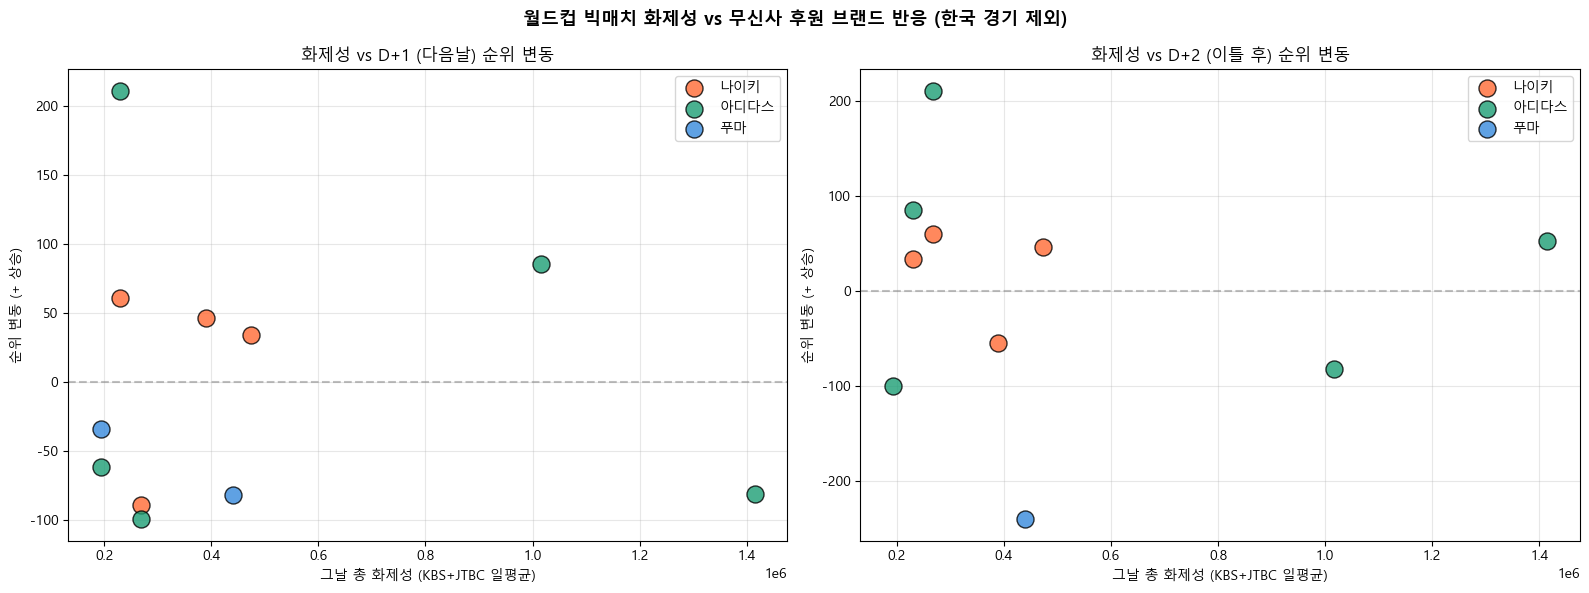

In [37]:
# === 빅매치 화제성 vs 무신사 후원 브랜드 D+1, D+2 반응 ===

print("=== 화제성 vs 순위 변동 (D+1, D+2 따로) ===\n")

분석_결과 = []

for _, row in 화제성_df.iterrows():
    브랜드 = row['브랜드']
    경기일 = row['경기일']
    다음날 = 경기일 + pd.Timedelta(days=1)
    이틀후 = 경기일 + pd.Timedelta(days=2)
    화제성 = row['그날_총_화제성']

    당일_순위 = df_target[(df_target['브랜드'] == 브랜드) &
                        (df_target['수집날짜'] == 경기일)]['순위'].mean()
    다음날_순위 = df_target[(df_target['브랜드'] == 브랜드) &
                          (df_target['수집날짜'] == 다음날)]['순위'].mean()
    이틀후_순위 = df_target[(df_target['브랜드'] == 브랜드) &
                          (df_target['수집날짜'] == 이틀후)]['순위'].mean()

    if pd.isna(당일_순위) or pd.isna(다음날_순위):
        continue

    변동_d1 = 당일_순위 - 다음날_순위
    변동_d2 = 다음날_순위 - 이틀후_순위 if pd.notna(이틀후_순위) else None

    print(f"[{경기일.strftime('%m/%d')} {브랜드}] 화제성: {화제성:,.0f}")
    print(f"  D+1: {당일_순위:.0f}위 → {다음날_순위:.0f}위 ({변동_d1:+.0f}위)")
    if 변동_d2 is not None:
        print(f"  D+2: {다음날_순위:.0f}위 → {이틀후_순위:.0f}위 ({변동_d2:+.0f}위)")
    else:
        print(f"  D+2: 데이터 없음")
    print()

    분석_결과.append({
        '브랜드': 브랜드,
        '경기일': 경기일,
        '화제성': 화제성,
        '변동_d1': 변동_d1,
        '변동_d2': 변동_d2,
    })

결과_df = pd.DataFrame(분석_결과)


# 상관관계 (D+1, D+2 각각)
print("\n=== 화제성 vs 순위 변동 상관관계 ===\n")

for d, col in [('D+1', '변동_d1'), ('D+2', '변동_d2')]:
    df_temp = 결과_df.dropna(subset=[col])
    if len(df_temp) >= 3:
        corr = df_temp['화제성'].corr(df_temp[col])
        print(f"  {d} 전체: 상관계수 {corr:.3f} (표본 {len(df_temp)}개)")
    else:
        print(f"  {d} 전체: 표본 부족 ({len(df_temp)}개)")

print()
for brand in ['나이키', '아디다스', '푸마']:
    bdf = 결과_df[결과_df['브랜드'] == brand]
    for d, col in [('D+1', '변동_d1'), ('D+2', '변동_d2')]:
        df_temp = bdf.dropna(subset=[col])
        if len(df_temp) >= 3:
            corr = df_temp['화제성'].corr(df_temp[col])
            print(f"  {brand} {d}: 상관계수 {corr:.3f} (표본 {len(df_temp)}개)")
        else:
            print(f"  {brand} {d}: 표본 부족 ({len(df_temp)}개)")
    print()


# 시각화: D+1, D+2 나란히
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {'나이키': '#FF6B35', '아디다스': '#1D9E75', '푸마': '#378ADD'}

for ax, (d, col) in zip(axes, [('D+1 (다음날)', '변동_d1'), ('D+2 (이틀 후)', '변동_d2')]):
    df_temp = 결과_df.dropna(subset=[col])
    for brand in ['나이키', '아디다스', '푸마']:
        bdf = df_temp[df_temp['브랜드'] == brand]
        if len(bdf) > 0:
            ax.scatter(bdf['화제성'], bdf[col],
                      s=150, color=colors[brand], label=brand,
                      edgecolors='black', linewidths=1, zorder=3, alpha=0.8)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('그날 총 화제성 (KBS+JTBC 일평균)')
    ax.set_ylabel('순위 변동 (+ 상승)')
    ax.set_title(f'화제성 vs {d} 순위 변동')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('월드컵 빅매치 화제성 vs 무신사 후원 브랜드 반응 (한국 경기 제외)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()